In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
import json
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['XLA_FLAGS'] = '--xla_gpu_enable_triton_gemm=false'

import numpy as np
import csv
import matplotlib.pyplot as plt
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
#tf.config.experimental.enable_op_determinism()


from scripts.train_decoder import train_and_evaluate_decoder
from scripts.train_encoder import train_and_evaluate_encoder

E0000 00:00:1791113318.114042 3897832 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791113318.116950 3897832 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791113318.124022 3897832 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791113318.124035 3897832 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791113318.124037 3897832 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791113318.124038 3897832 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
resolutions = [100, 200, 400, 800]
results = []

base_data_dir = os.path.join('data', 'multiresolution')
times_file = os.path.join(base_data_dir, 'generation_times.json')

if os.path.exists(times_file):
    with open(times_file, 'r') as f:
        time_per_res = {int(k): float(v) for k, v in json.load(f).items()}
else:
    time_per_res = {}



TRAINING - DECODER 



[DECODER] Adam + L-BFGS for grid 100x100
Loading Parametric FEM data from:
data/multiresolution/100x100/train.npz
data/multiresolution/100x100/val.npz
data/multiresolution/100x100/test.npz
Applied pre-computed noise.
U_SCALE: 0.06768616288900375


I0000 00:00:1791038463.624216  226293 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


Shape x_train: (814980, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)

Starting Adam optimization...


I0000 00:00:1791038465.450534  226293 service.cc:152] XLA service 0x62b43c7215a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791038465.450607  226293 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1791038465.929377  226293 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1791038467.850348  226293 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch    0 | Loss: 1.8674e+00 | PDE: 3.7598e-04 | Dir: 2.3943e-03 | Neu: 2.9497e-05 | Data: 1.6276e-01 | Val: 2.5397e-02
Epoch  500 | Loss: 4.0966e-02 | PDE: 4.8644e-04 | Dir: 3.3400e-06 | Neu: 1.3309e-04 | Data: 4.0144e-03 | Val: 3.5622e-03
Epoch 1000 | Loss: 3.7932e-02 | PDE: 4.8950e-03 | Dir: 2.0198e-06 | Neu: 1.1029e-04 | Data: 3.2834e-03 | Val: 3.1869e-03
Epoch 1500 | Loss: 3.1988e-02 | PDE: 3.0689e-03 | Dir: 7.7730e-07 | Neu: 9.6043e-05 | Data: 2.8840e-03 | Val: 3.0321e-03
Epoch 2000 | Loss: 3.3637e-02 | PDE: 2.1240e-03 | Dir: 9.6244e-07 | Neu: 9.8123e-05 | Data: 3.1416e-03 | Val: 3.0146e-03
Epoch 2500 | Loss: 3.3654e-02 | PDE: 2.2255e-03 | Dir: 6.2108e-07 | Neu: 8.9994e-05 | Data: 3.1366e-03 | Val: 2.9397e-03
Epoch 3000 | Loss: 3.0988e-02 | PDE: 2.2431e-03 | Dir: 6.0860e-07 | Neu: 8.8600e-05 | Data: 2.8683e-03 | Val: 2.7978e-03
Epoch 3500 | Loss: 2.3632e-02 | PDE: 2.9862e-03 | Dir: 8.5109e-07 | Neu: 9.2289e-05 | Data: 2.0560e-03 | Val: 1.9786e-03
Epoch 4000 | Loss: 9.7663e-03 | 

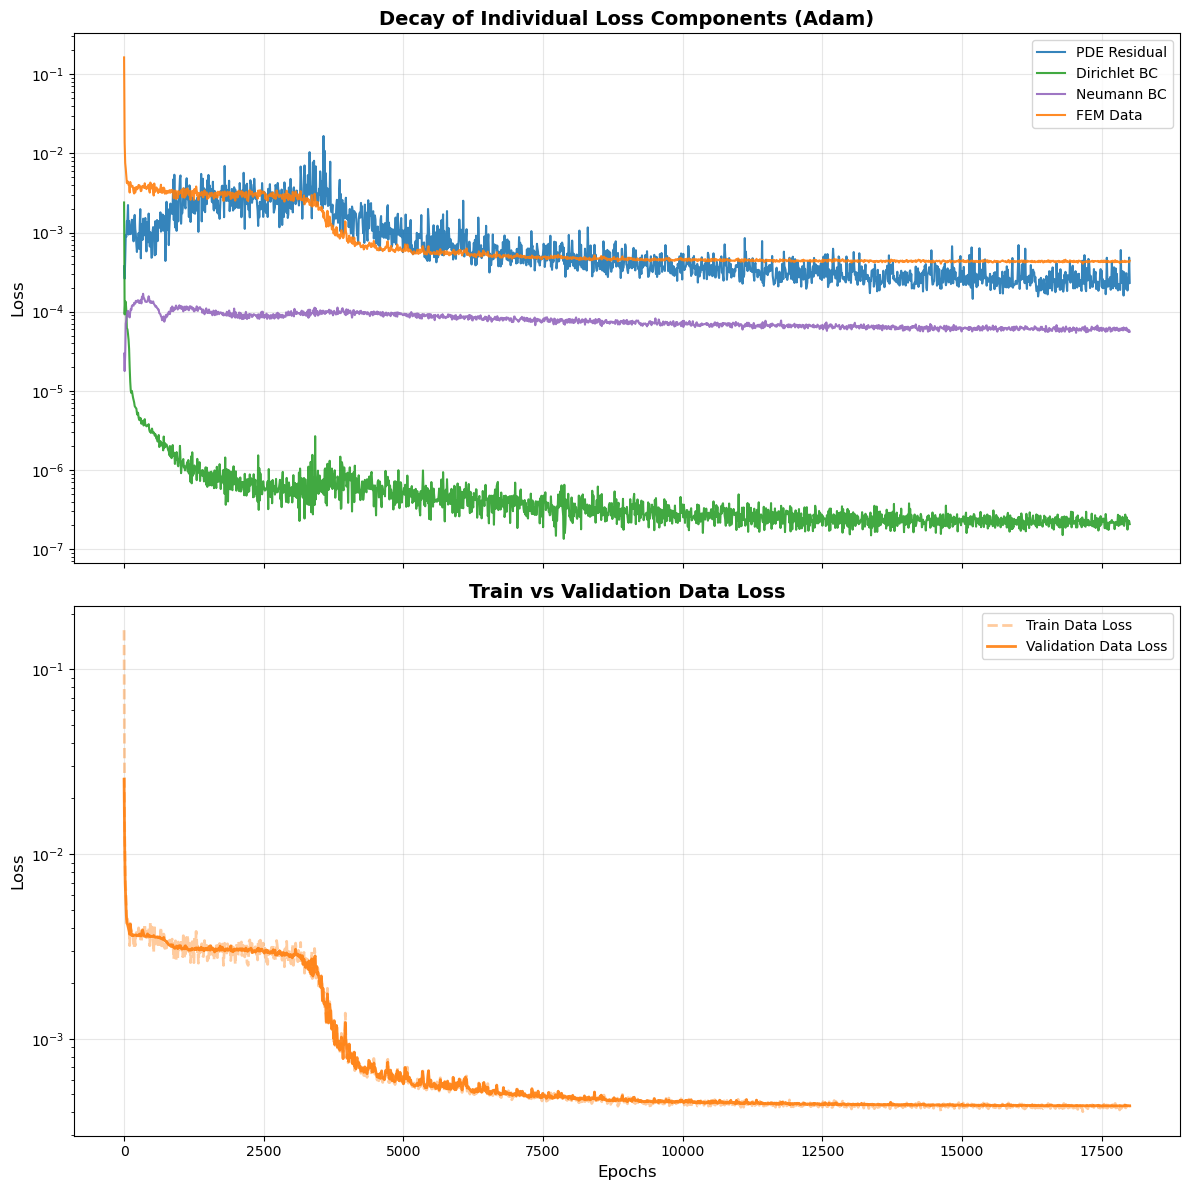

Loading Parametric FEM data for L-BFGS from:
data/multiresolution/100x100/train.npz
data/multiresolution/100x100/val.npz
data/multiresolution/100x100/test.npz
Applied pre-computed noise.
U_SCALE (loaded): 0.06768616288900375
Shape x_train: (25000, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)
Transfer Learning from Adam weights: models/error_analysis/100x100/decoder_adam.weights.h5

Starting L-BFGS optimization...
Call to loss_grad: 0 | Loss: 0.0046056113969586464 | PDE: 0.00033344420894886051 | Dir: 2.1623172585783977e-07 | Neu: 6.138804317119824e-05 | Data: 0.000424993013499229 | Validation: 0.00043267141629119588
Call to loss_grad: 500 | Loss: 0.0042793176118693967 | PDE: 0.00010332704608443704 | Dir: 2.4909214529288453e-07 | Neu: 5.90657909553995e-05 | Data: 0.00041504906933461169 | Validation: 0.0004253337393583435
Call to loss_grad: 1000 | Loss: 0.0042254679801498989 | PDE: 9.2533195618081836e-05 | Dir: 2.2393907101179213e-07 | Neu: 5.7985295352095138e-05 | Data: 0.000

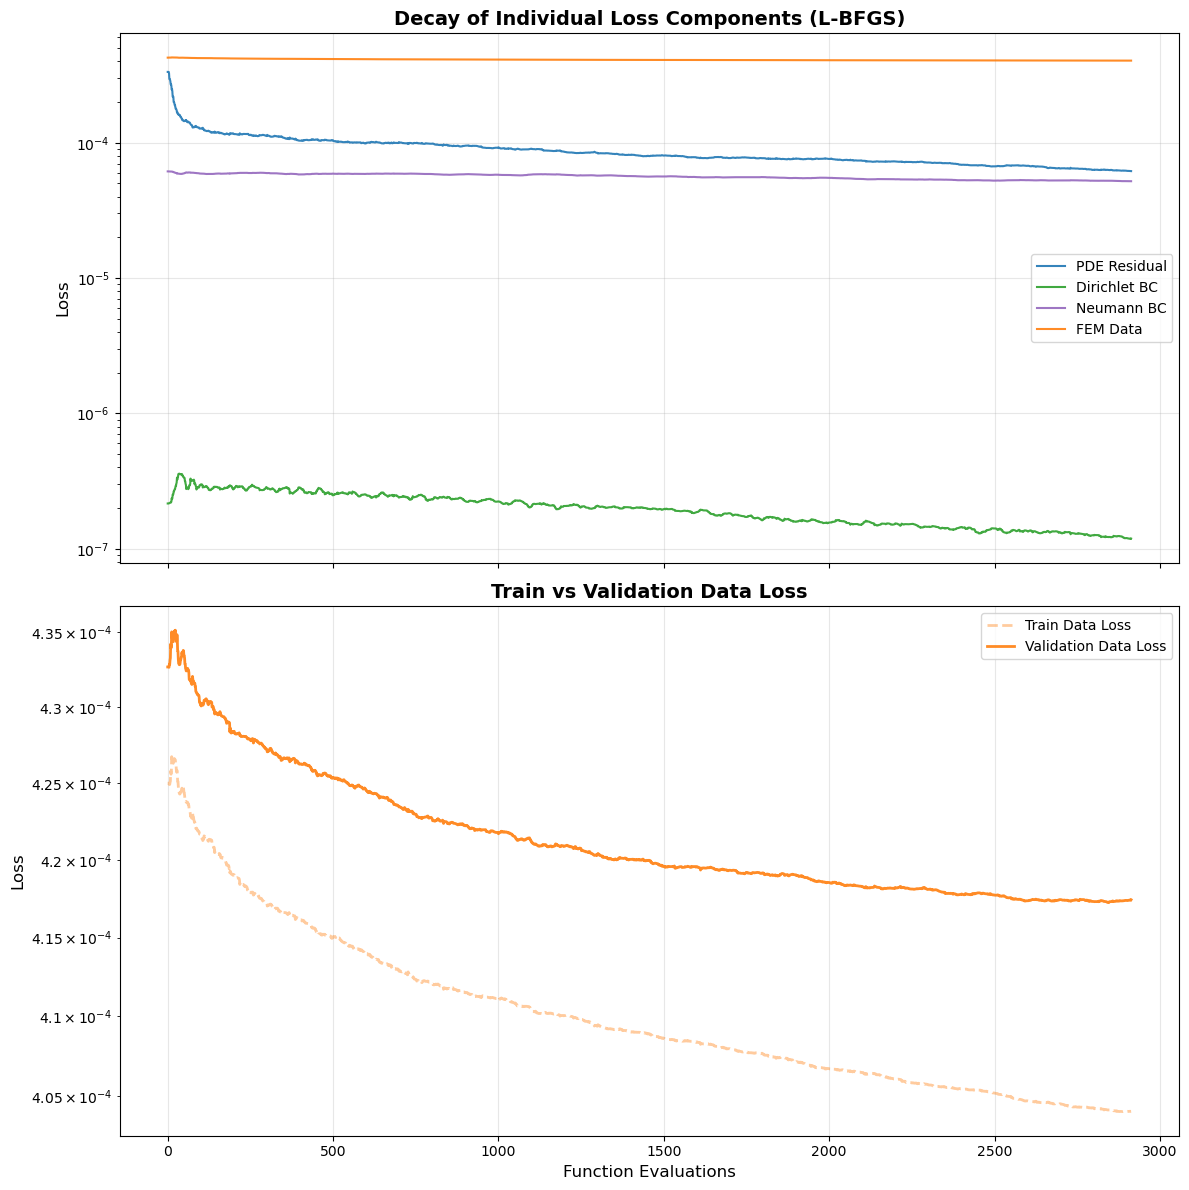

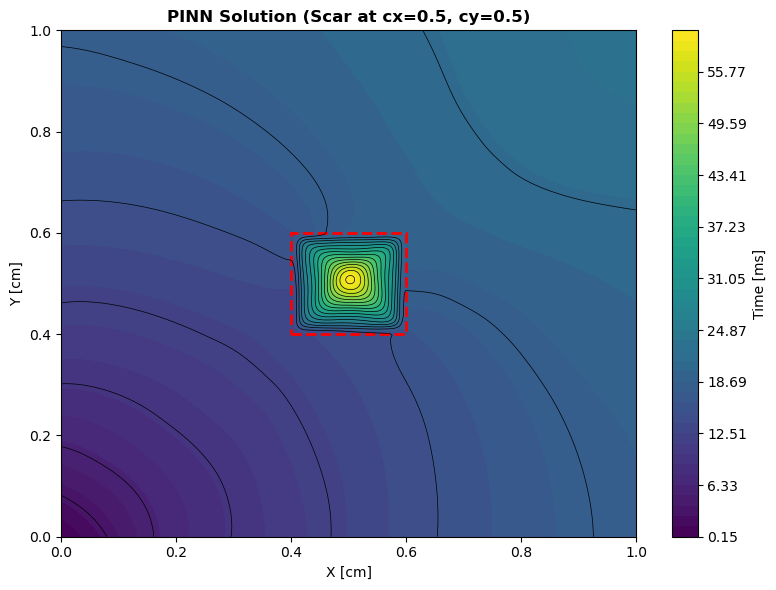

L2 Relative Error vs FEM   : 2.0581%
Mean Absolute Error (Phys) : 0.1597 ms

[DECODER] Adam + L-BFGS for grid 200x200
Loading Parametric FEM data from:
data/multiresolution/200x200/train.npz
data/multiresolution/200x200/val.npz
data/multiresolution/200x200/test.npz
Applied pre-computed noise.
U_SCALE: 0.06774014234542847
Shape x_train: (814980, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)

Starting Adam optimization...
Epoch    0 | Loss: 1.8504e+00 | PDE: 3.7648e-04 | Dir: 2.3982e-03 | Neu: 2.9545e-05 | Data: 1.6102e-01 | Val: 2.4988e-02
Epoch  500 | Loss: 4.1370e-02 | PDE: 4.9154e-04 | Dir: 3.3272e-06 | Neu: 1.3538e-04 | Data: 4.0544e-03 | Val: 3.6129e-03
Epoch 1000 | Loss: 3.8422e-02 | PDE: 4.9447e-03 | Dir: 2.0526e-06 | Neu: 1.1442e-04 | Data: 3.3271e-03 | Val: 3.1975e-03
Epoch 1500 | Loss: 3.2320e-02 | PDE: 3.0448e-03 | Dir: 8.3727e-07 | Neu: 9.7533e-05 | Data: 2.9191e-03 | Val: 3.0470e-03
Epoch 2000 | Loss: 3.3786e-02 | PDE: 2.1148e-03 | Dir: 1.0137e-06 | Neu: 9.9710e-

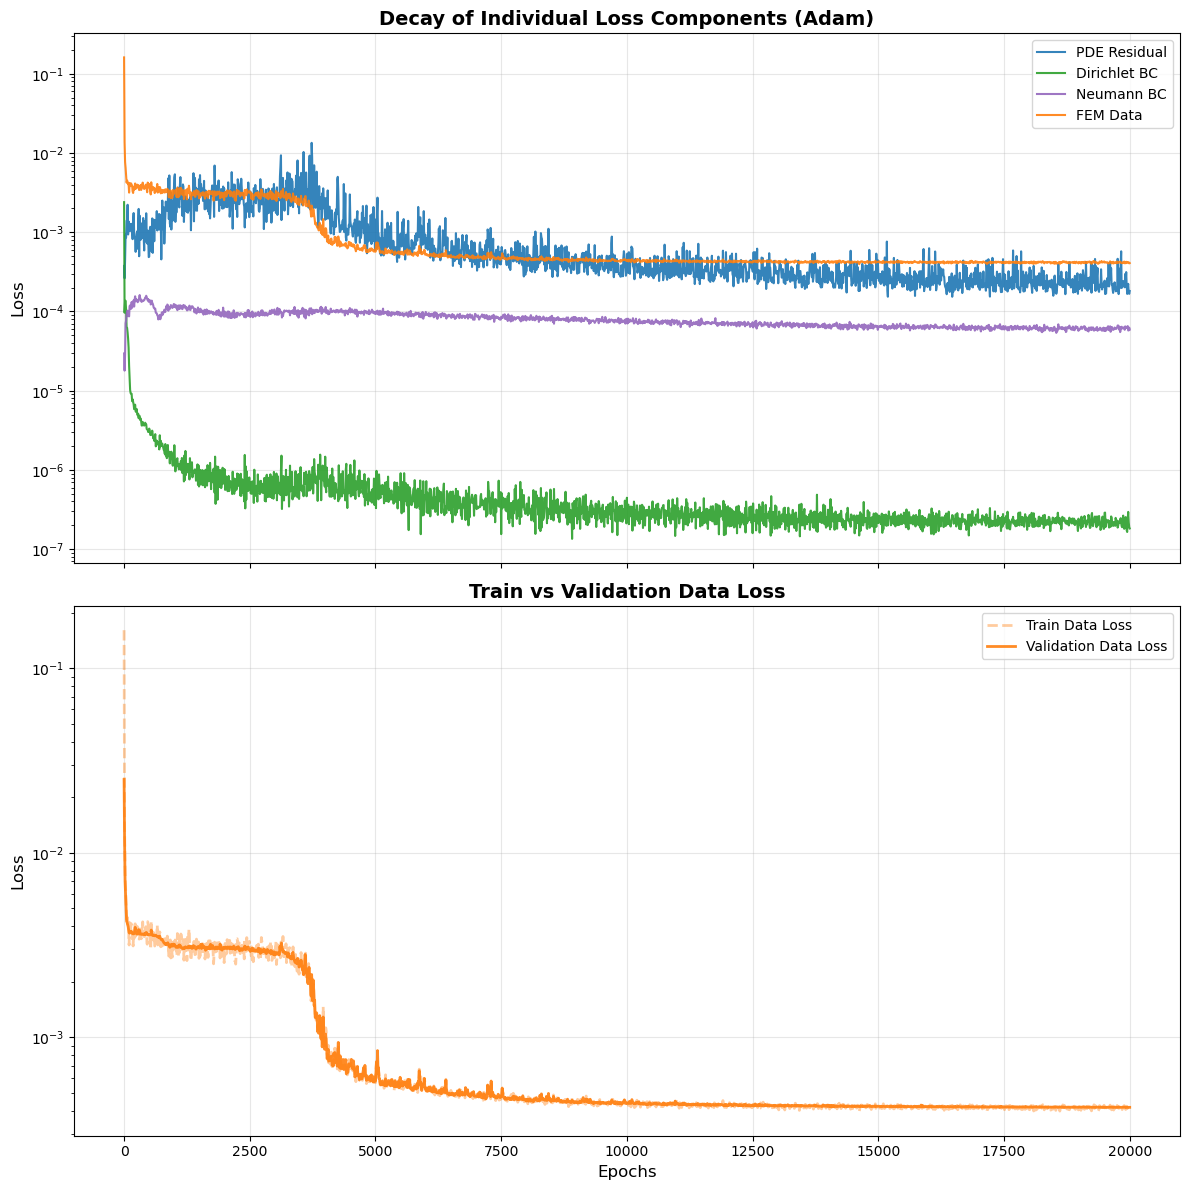

Loading Parametric FEM data for L-BFGS from:
data/multiresolution/200x200/train.npz
data/multiresolution/200x200/val.npz
data/multiresolution/200x200/test.npz
Applied pre-computed noise.
U_SCALE (loaded): 0.06774014234542847
Shape x_train: (25000, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)
Transfer Learning from Adam weights: models/error_analysis/200x200/decoder_adam.weights.h5

Starting L-BFGS optimization...
Call to loss_grad: 0 | Loss: 0.0043785596593718433 | PDE: 0.0002256714841683373 | Dir: 2.997856979477391e-07 | Neu: 6.149971966583619e-05 | Data: 0.00041222946082120738 | Validation: 0.00041632693369857729
Call to loss_grad: 500 | Loss: 0.0041401670209625574 | PDE: 9.3658383512339429e-05 | Dir: 2.4572723367339557e-07 | Neu: 6.097491660810386e-05 | Data: 0.00040213261649167973 | Validation: 0.00040931917665789957
Call to loss_grad: 1000 | Loss: 0.00409660444228154 | PDE: 8.2970055625007787e-05 | Dir: 2.1097817153452102e-07 | Neu: 5.9272772624467759e-05 | Data: 0.000

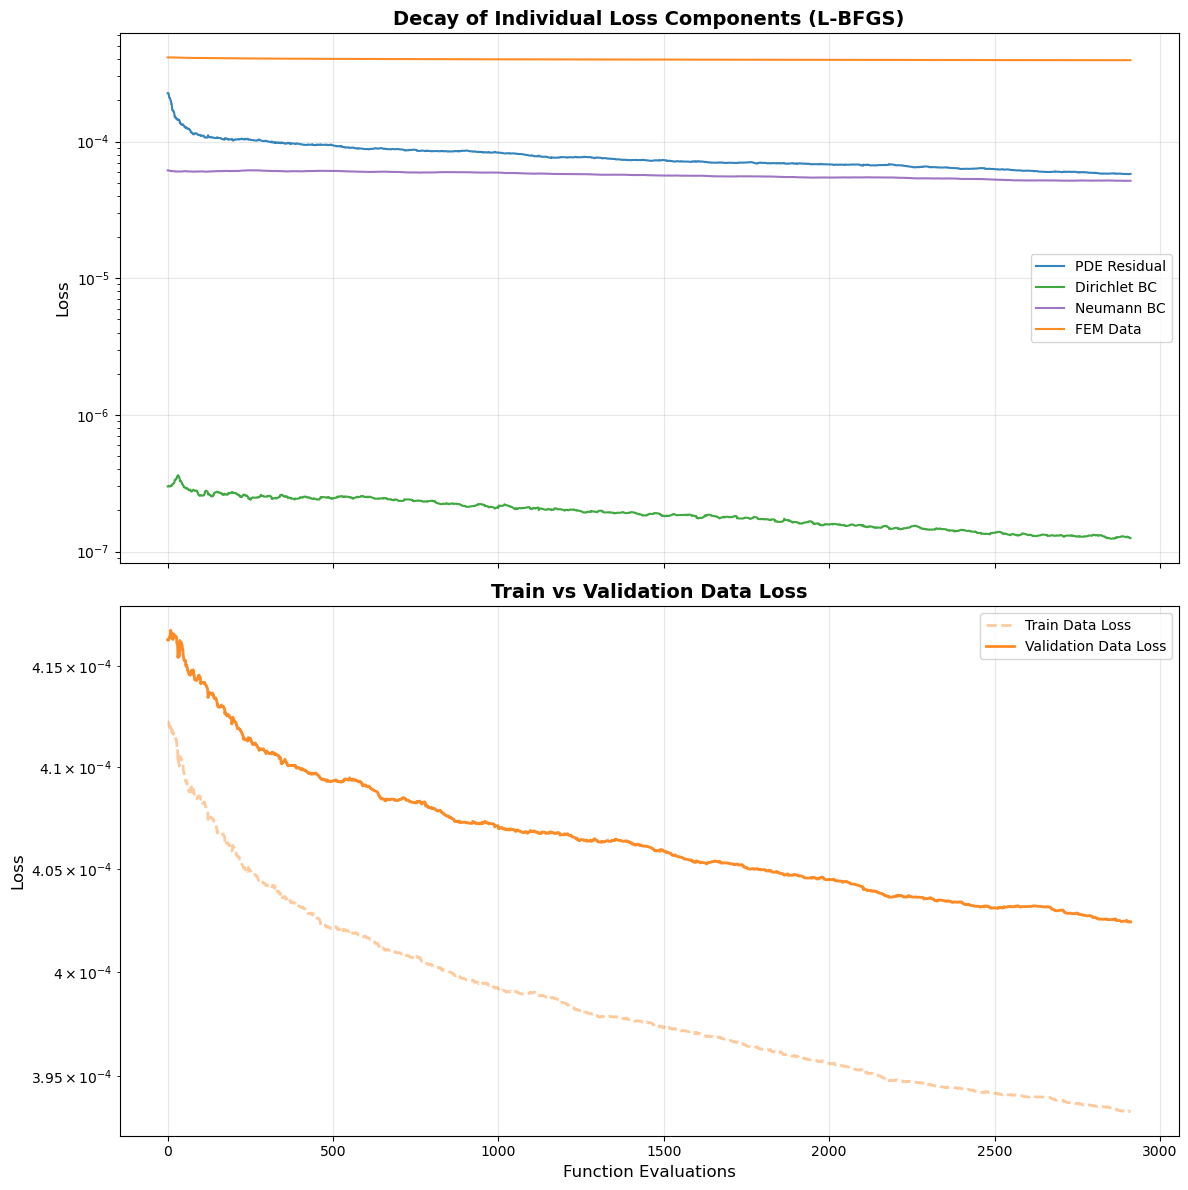

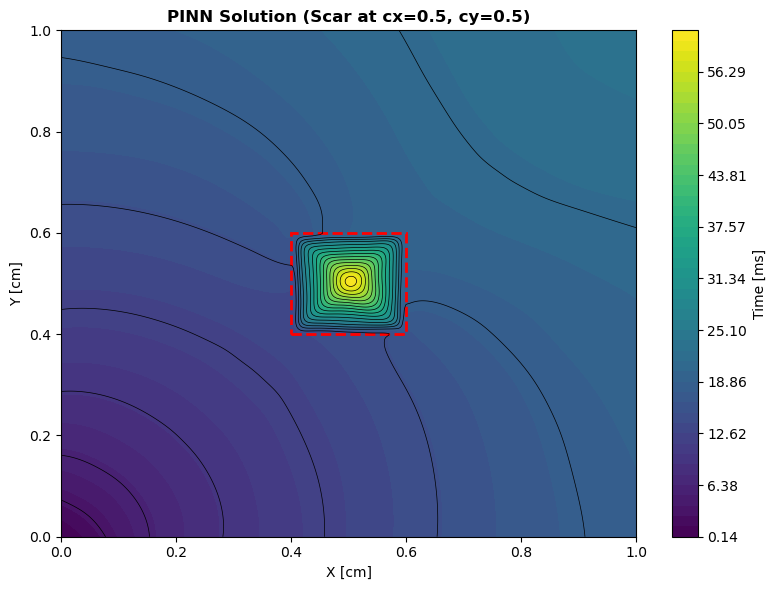

L2 Relative Error vs FEM   : 1.4647%
Mean Absolute Error (Phys) : 0.1389 ms

[DECODER] Adam + L-BFGS for grid 400x400
Loading Parametric FEM data from:
data/multiresolution/400x400/train.npz
data/multiresolution/400x400/val.npz
data/multiresolution/400x400/test.npz
Applied pre-computed noise.
U_SCALE: 0.06773888319730759
Shape x_train: (814980, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)

Starting Adam optimization...
Epoch    0 | Loss: 1.8403e+00 | PDE: 3.7659e-04 | Dir: 2.3981e-03 | Neu: 2.9543e-05 | Data: 1.6001e-01 | Val: 2.4803e-02
Epoch  500 | Loss: 4.1987e-02 | PDE: 4.9887e-04 | Dir: 3.4041e-06 | Neu: 1.3874e-04 | Data: 4.1146e-03 | Val: 3.7678e-03
Epoch 1000 | Loss: 3.8853e-02 | PDE: 5.1003e-03 | Dir: 2.0855e-06 | Neu: 1.1386e-04 | Data: 3.3543e-03 | Val: 3.2440e-03
Epoch 1500 | Loss: 3.2816e-02 | PDE: 3.1414e-03 | Dir: 8.6411e-07 | Neu: 9.9070e-05 | Data: 2.9587e-03 | Val: 3.0911e-03
Epoch 2000 | Loss: 3.4162e-02 | PDE: 2.1799e-03 | Dir: 1.1016e-06 | Neu: 1.0183e-

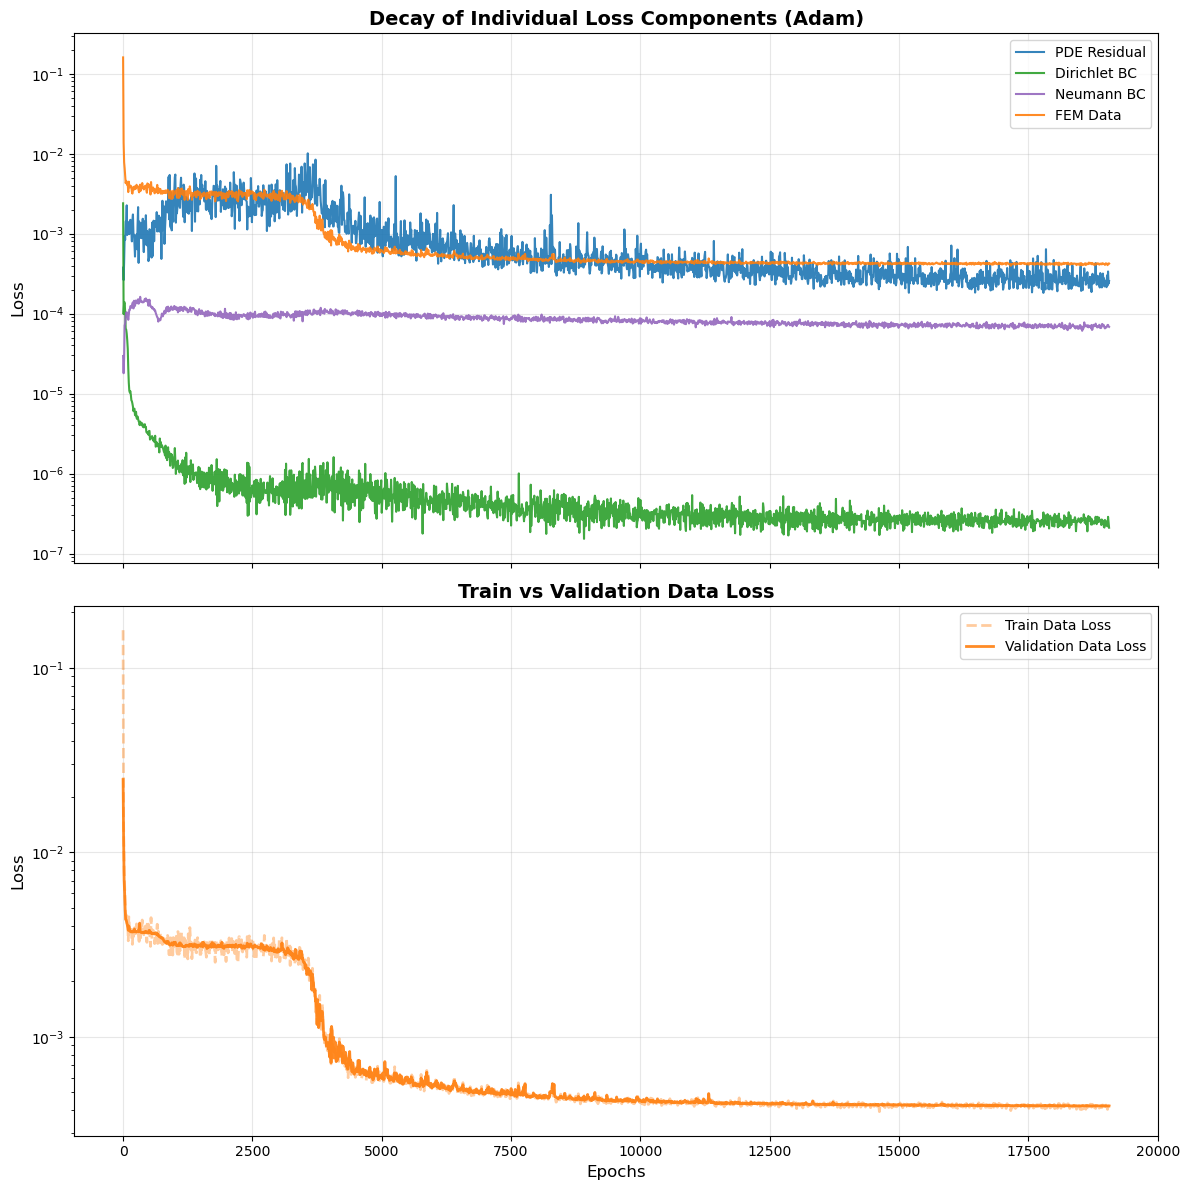

Loading Parametric FEM data for L-BFGS from:
data/multiresolution/400x400/train.npz
data/multiresolution/400x400/val.npz
data/multiresolution/400x400/test.npz
Applied pre-computed noise.
U_SCALE (loaded): 0.06773888319730759
Shape x_train: (25000, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)
Transfer Learning from Adam weights: models/error_analysis/400x400/decoder_adam.weights.h5

Starting L-BFGS optimization...
Call to loss_grad: 0 | Loss: 0.0045295262603243453 | PDE: 0.00034390065785443294 | Dir: 2.1666399967237e-07 | Neu: 7.2000708924280839e-05 | Data: 0.00041632391954134326 | Validation: 0.00042042484570208364
Call to loss_grad: 500 | Loss: 0.0041924836125320254 | PDE: 0.00011911301904153327 | Dir: 2.6632822303009745e-07 | Neu: 6.9459453647531012e-05 | Data: 0.00040460431766510074 | Validation: 0.00041147659034257937
Call to loss_grad: 1000 | Loss: 0.0041347247327047712 | PDE: 0.00011056938601362108 | Dir: 2.3650806839671082e-07 | Neu: 6.7883542843810458e-05 | Data: 0.

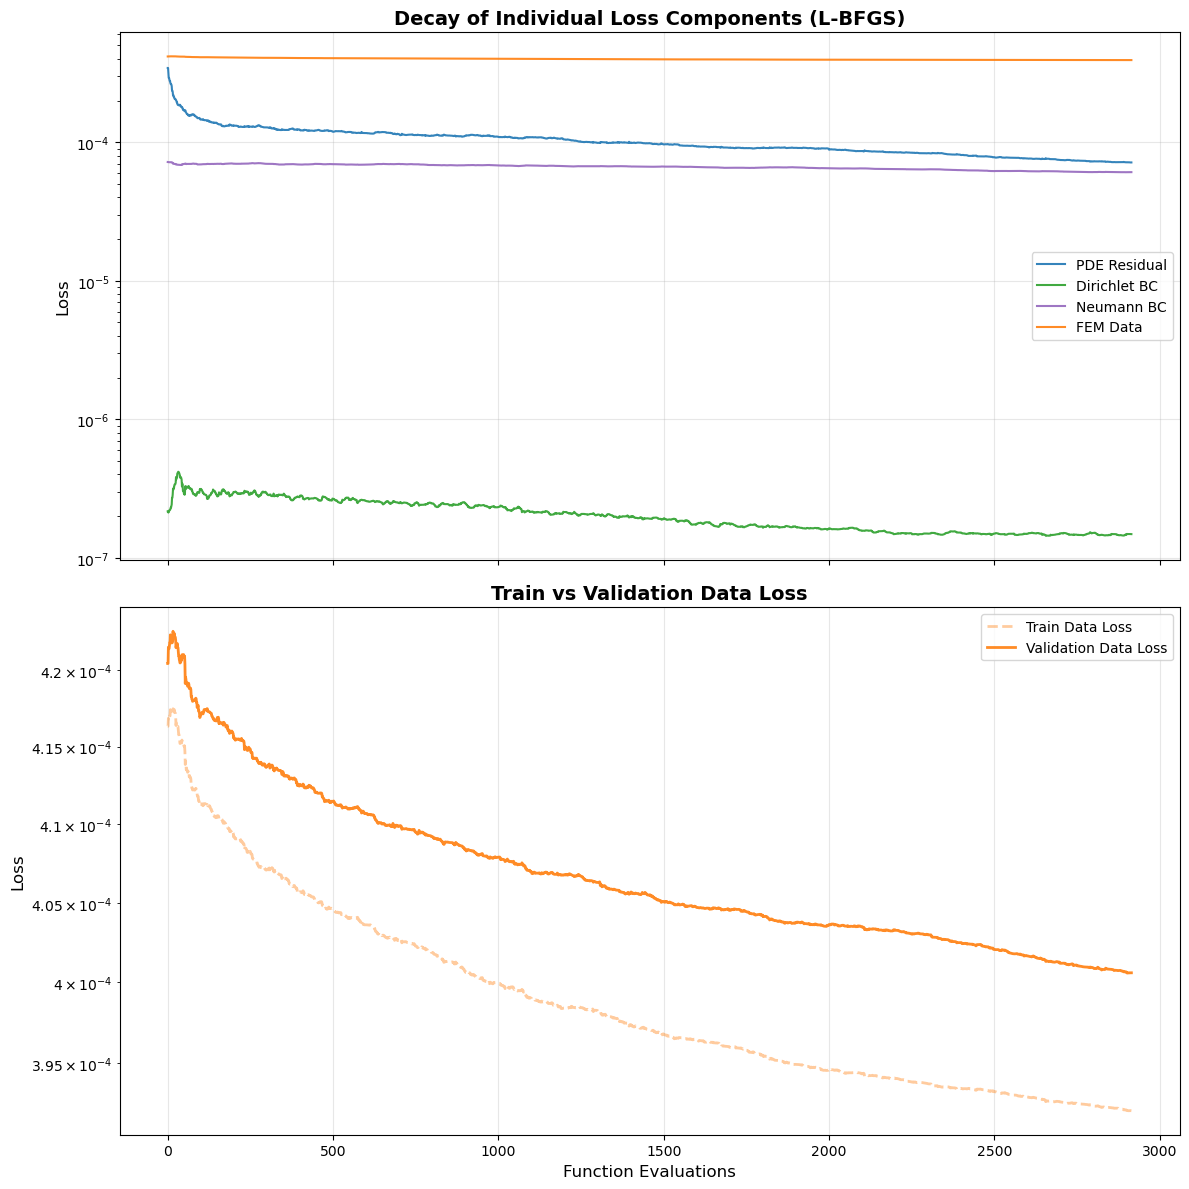

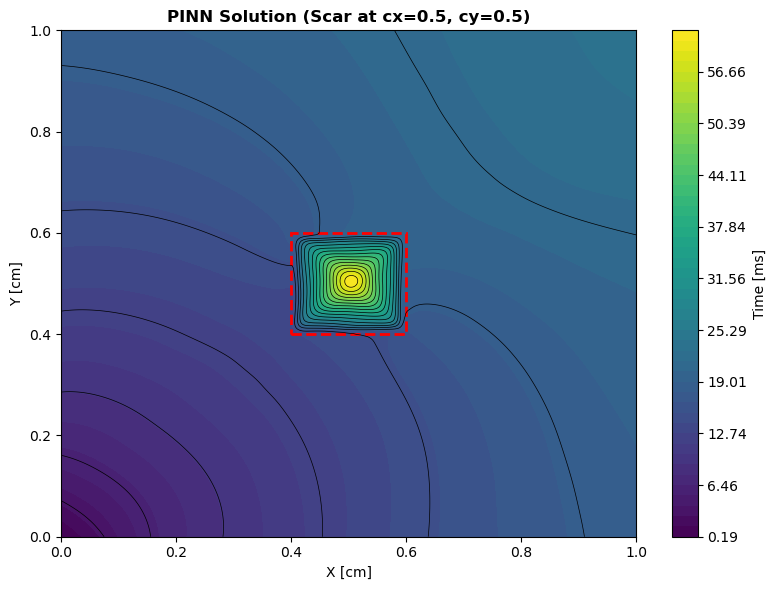

L2 Relative Error vs FEM   : 1.4073%
Mean Absolute Error (Phys) : 0.1397 ms

[DECODER] Adam + L-BFGS for grid 800x800
Loading Parametric FEM data from:
data/multiresolution/800x800/train.npz
data/multiresolution/800x800/val.npz
data/multiresolution/800x800/test.npz
Applied pre-computed noise.
U_SCALE: 0.06782476603984833
Shape x_train: (814980, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)

Starting Adam optimization...
Epoch    0 | Loss: 1.8381e+00 | PDE: 3.7711e-04 | Dir: 2.4041e-03 | Neu: 2.9618e-05 | Data: 1.5974e-01 | Val: 2.4736e-02
Epoch  500 | Loss: 4.2462e-02 | PDE: 4.9228e-04 | Dir: 3.3839e-06 | Neu: 1.3658e-04 | Data: 4.1630e-03 | Val: 3.7812e-03
Epoch 1000 | Loss: 3.9125e-02 | PDE: 5.1167e-03 | Dir: 2.1335e-06 | Neu: 1.1615e-04 | Data: 3.3794e-03 | Val: 3.2537e-03
Epoch 1500 | Loss: 3.2897e-02 | PDE: 3.1059e-03 | Dir: 8.7710e-07 | Neu: 9.9802e-05 | Data: 2.9702e-03 | Val: 3.1024e-03
Epoch 2000 | Loss: 3.4350e-02 | PDE: 2.1603e-03 | Dir: 1.1123e-06 | Neu: 1.0323e-

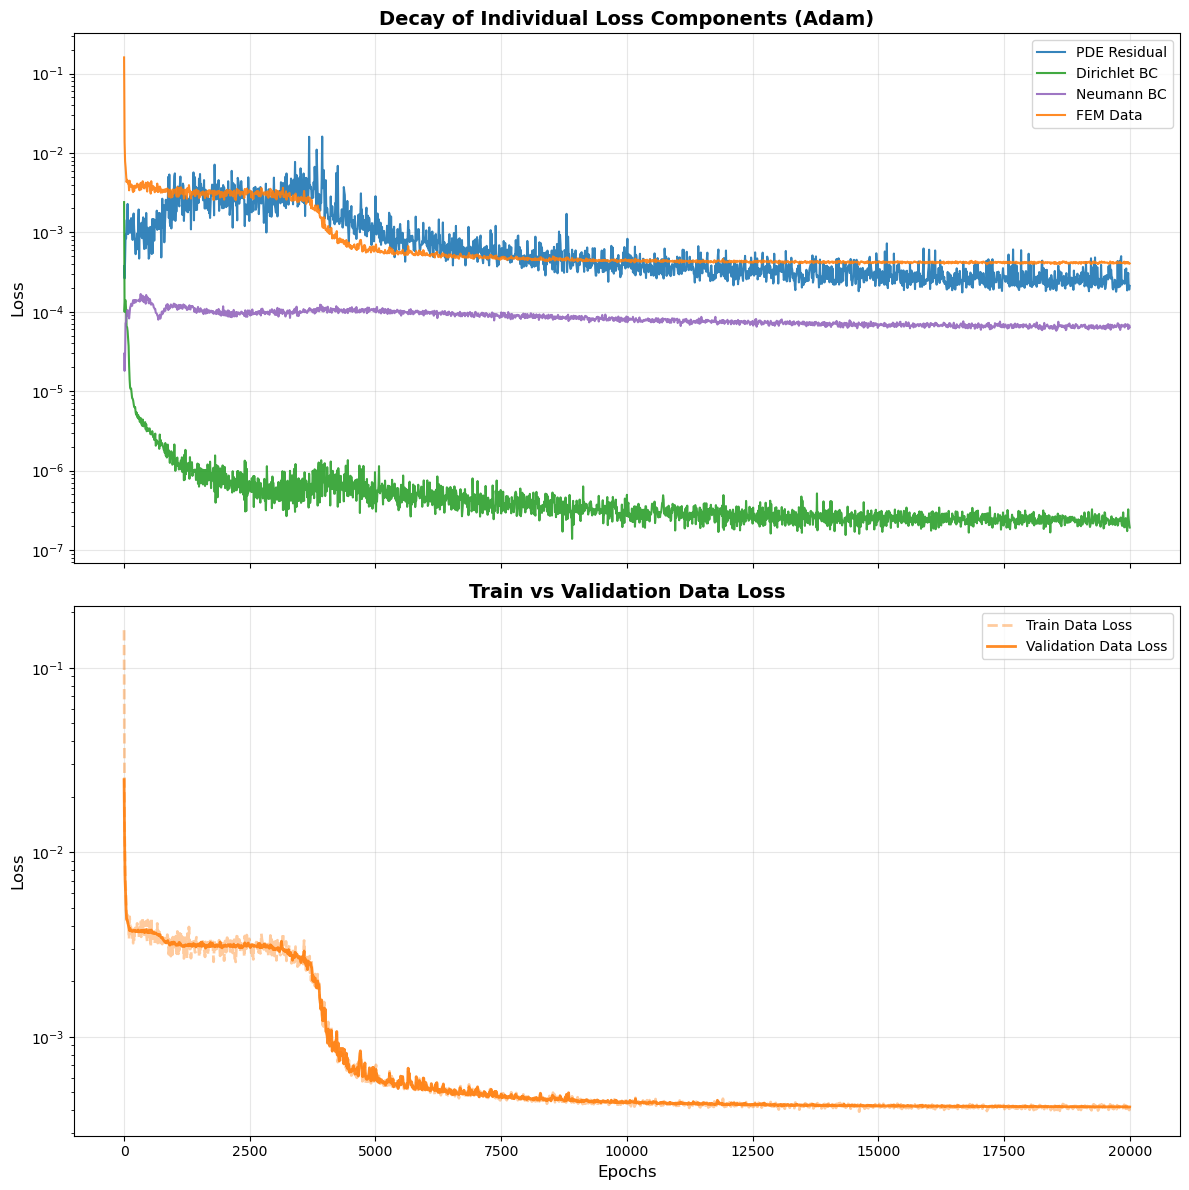

Loading Parametric FEM data for L-BFGS from:
data/multiresolution/800x800/train.npz
data/multiresolution/800x800/val.npz
data/multiresolution/800x800/test.npz
Applied pre-computed noise.
U_SCALE (loaded): 0.06782476603984833
Shape x_train: (25000, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)
Transfer Learning from Adam weights: models/error_analysis/800x800/decoder_adam.weights.h5

Starting L-BFGS optimization...
Call to loss_grad: 0 | Loss: 0.0044484776600198306 | PDE: 0.00030042262080550483 | Dir: 2.4482871193944968e-07 | Neu: 6.6705404342227471e-05 | Data: 0.00041229051139769584 | Validation: 0.00041556832096399318
Call to loss_grad: 500 | Loss: 0.004148780866847895 | PDE: 0.0001098897183577529 | Dir: 2.5021662072805234e-07 | Neu: 6.54033598112151e-05 | Data: 0.00040132154528192248 | Validation: 0.00040768315909433649
Call to loss_grad: 1000 | Loss: 0.0040899059836952013 | PDE: 9.4879246034387929e-05 | Dir: 2.1457087885142617e-07 | Neu: 6.37483137652479e-05 | Data: 0.000

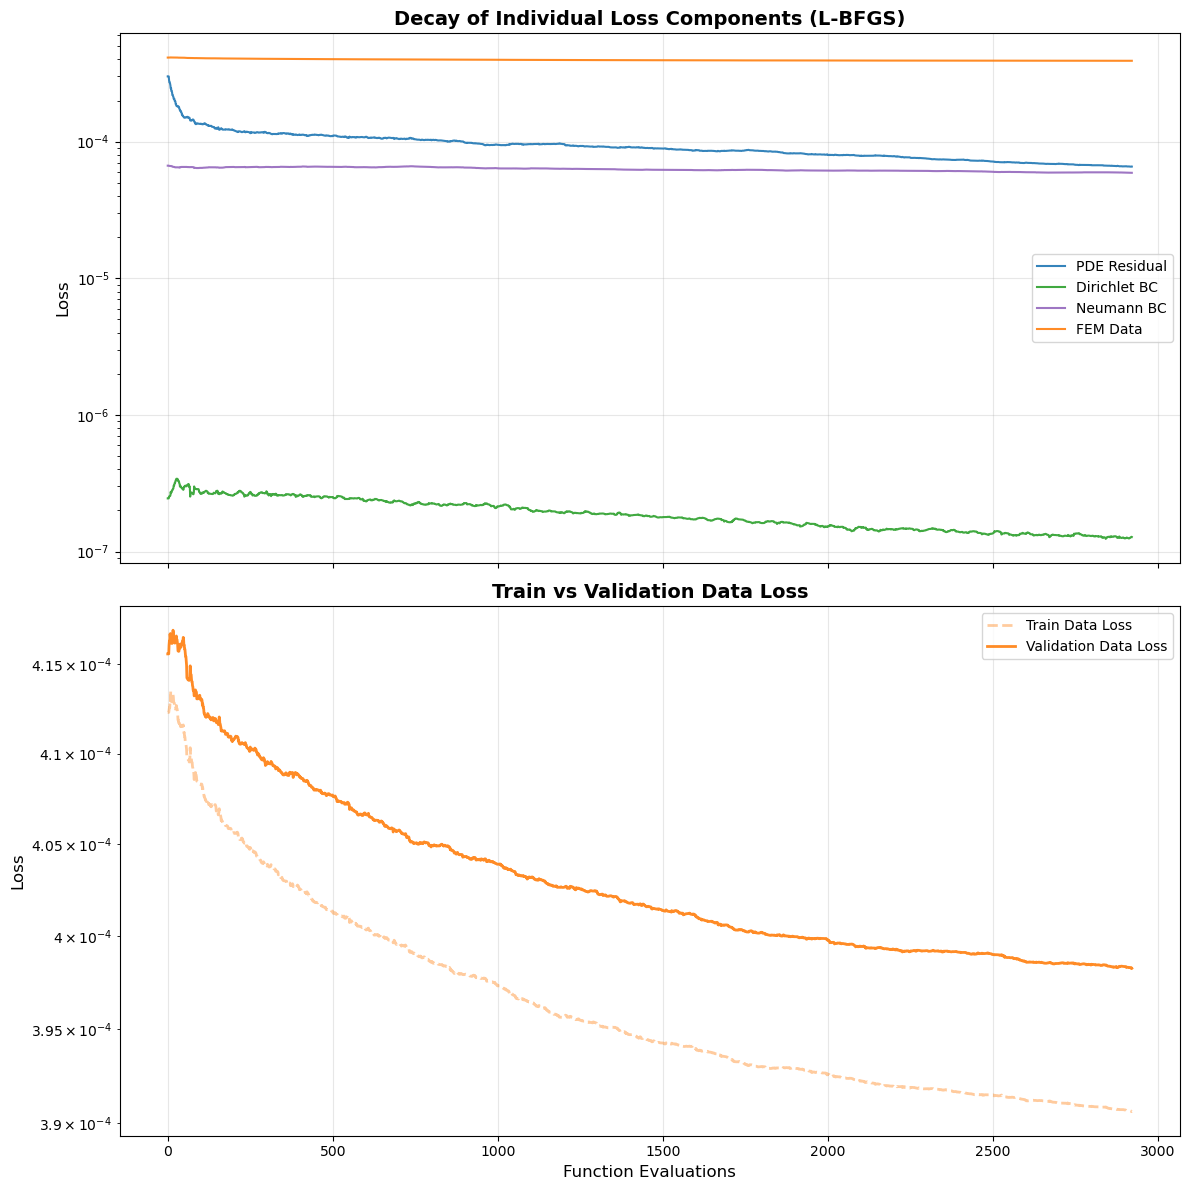

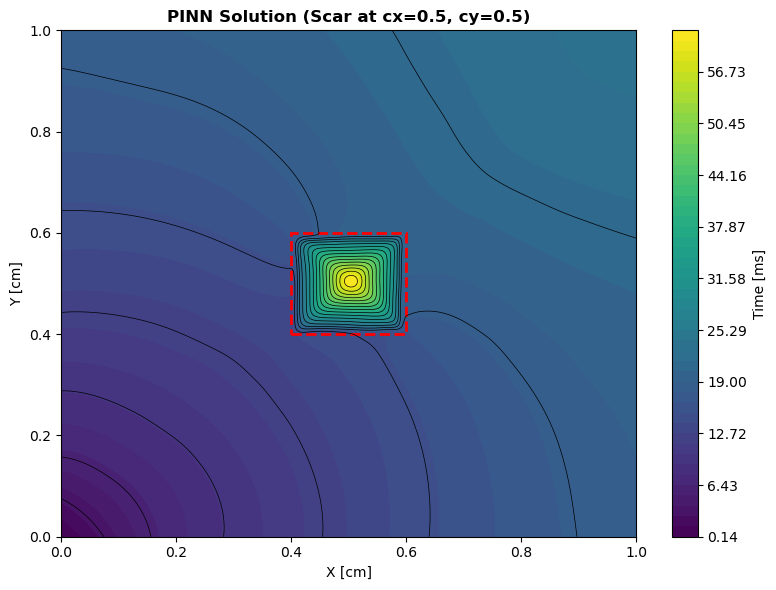

L2 Relative Error vs FEM   : 1.3331%
Mean Absolute Error (Phys) : 0.1362 ms


In [3]:
print("\n\nTRAINING - DECODER \n\n")

R_A = 1.0 / resolutions[0]

for N in resolutions:
    grid_name = f"{N}x{N}"
    data_dir = os.path.join(base_data_dir, grid_name)

    model_dir = os.path.join('models', 'error_analysis', grid_name)
    os.makedirs(model_dir, exist_ok=True)

    result_dir = os.path.join('results', 'error_analysis', grid_name)
    os.makedirs(result_dir, exist_ok=True)

    metrics_file = os.path.join(model_dir, "metrics.json")

    res_metrics = {}
    if os.path.exists(metrics_file):
        with open(metrics_file, 'r') as f:
            res_metrics = json.load(f)
            
    if 'decoder_lbfgs' in res_metrics.get("times", {}):
        print(f"[{grid_name}] Decoder already trained. Skipping.")
        continue
        
    print(f"\n[DECODER] Adam + L-BFGS for grid {grid_name}")
    model_lbfgs, u_scale, l2_err_pinn, mae_err_pinn, t_adam, t_lbfgs = train_and_evaluate_decoder(
        nx=N, ny=N, r_a=R_A, output_dir=model_dir, result_dir=result_dir, data_dir=data_dir
    )

    res_metrics['Grid'] = grid_name
    res_metrics['u_scale'] = float(u_scale)
    res_metrics.setdefault('times', {})['fem_generation'] = time_per_res.get(N, 0.0)
    res_metrics['times']['decoder_adam'] = t_adam
    res_metrics['times']['decoder_lbfgs'] = t_lbfgs
    res_metrics.setdefault('errors', {})['pinn_l2_rel'] = float(l2_err_pinn)
    res_metrics['errors']['pinn_mae'] = float(mae_err_pinn)
    
    with open(metrics_file, 'w') as f:
        json.dump(res_metrics, f, indent=4)



TRAINING - ENCODER PHASE



[ENCODER] Adam for grid 100x100
[SENSORS] Used sensors saved in: data/multiresolution/sensor_idx.npy


I0000 00:00:1791113322.287715 3897832 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


Shape y_train: (799, 200)  |  Shape u_train: (799, 2)
Shape y_val:   (99, 200)  |  Shape u_val:   (99, 2)
Shape y_test:  (101, 200)  |  Shape u_test:  (101, 2)
sigma_noise (scaled): 0.01966
Decoder weights loaded: models/error_analysis/100x100/decoder_lbfgs.weights.h5


I0000 00:00:1791113324.557447 3897832 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5b7ae1555ea0



Starting Encoder Adam optimization...


I0000 00:00:1791113325.780627 3897832 service.cc:152] XLA service 0x5b7af99df810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791113325.780674 3897832 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1791113326.159673 3897832 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1791113327.297303 3897832 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch    0 | Loss: 1.3964e+03 | Val Loss: 1.2340e+03
   train: prior_trace_inv: 4.144e-08 | prior_mean: 2.260e+00 | prior_trace: 1.400e-08 | data_mean: 1.394e+03 | data_trace: 1.627e-05
   val:   prior_trace_inv: 1.111e-07 | prior_mean: 1.005e+01 | prior_trace: 6.259e-09 | data_mean: 1.224e+03 | data_trace: 5.731e-07
Epoch  100 | Loss: 1.2706e+03 | Val Loss: 1.1286e+03
   train: prior_trace_inv: 1.005e-07 | prior_mean: 4.666e+00 | prior_trace: 6.346e-09 | data_mean: 1.266e+03 | data_trace: 9.019e-08
   val:   prior_trace_inv: 9.283e-08 | prior_mean: 4.160e+00 | prior_trace: 6.712e-09 | data_mean: 1.124e+03 | data_trace: 8.117e-08
Epoch  200 | Loss: 3.3337e+02 | Val Loss: 3.2120e+02
   train: prior_trace_inv: 1.263e-06 | prior_mean: 1.096e+00 | prior_trace: 9.308e-10 | data_mean: 3.323e+02 | data_trace: 2.040e-06
   val:   prior_trace_inv: 1.313e-06 | prior_mean: 8.805e-01 | prior_trace: 5.821e-10 | data_mean: 3.203e+02 | data_trace: 1.903e-06
Epoch  300 | Loss: 2.3189e+02 | Val Loss: 2

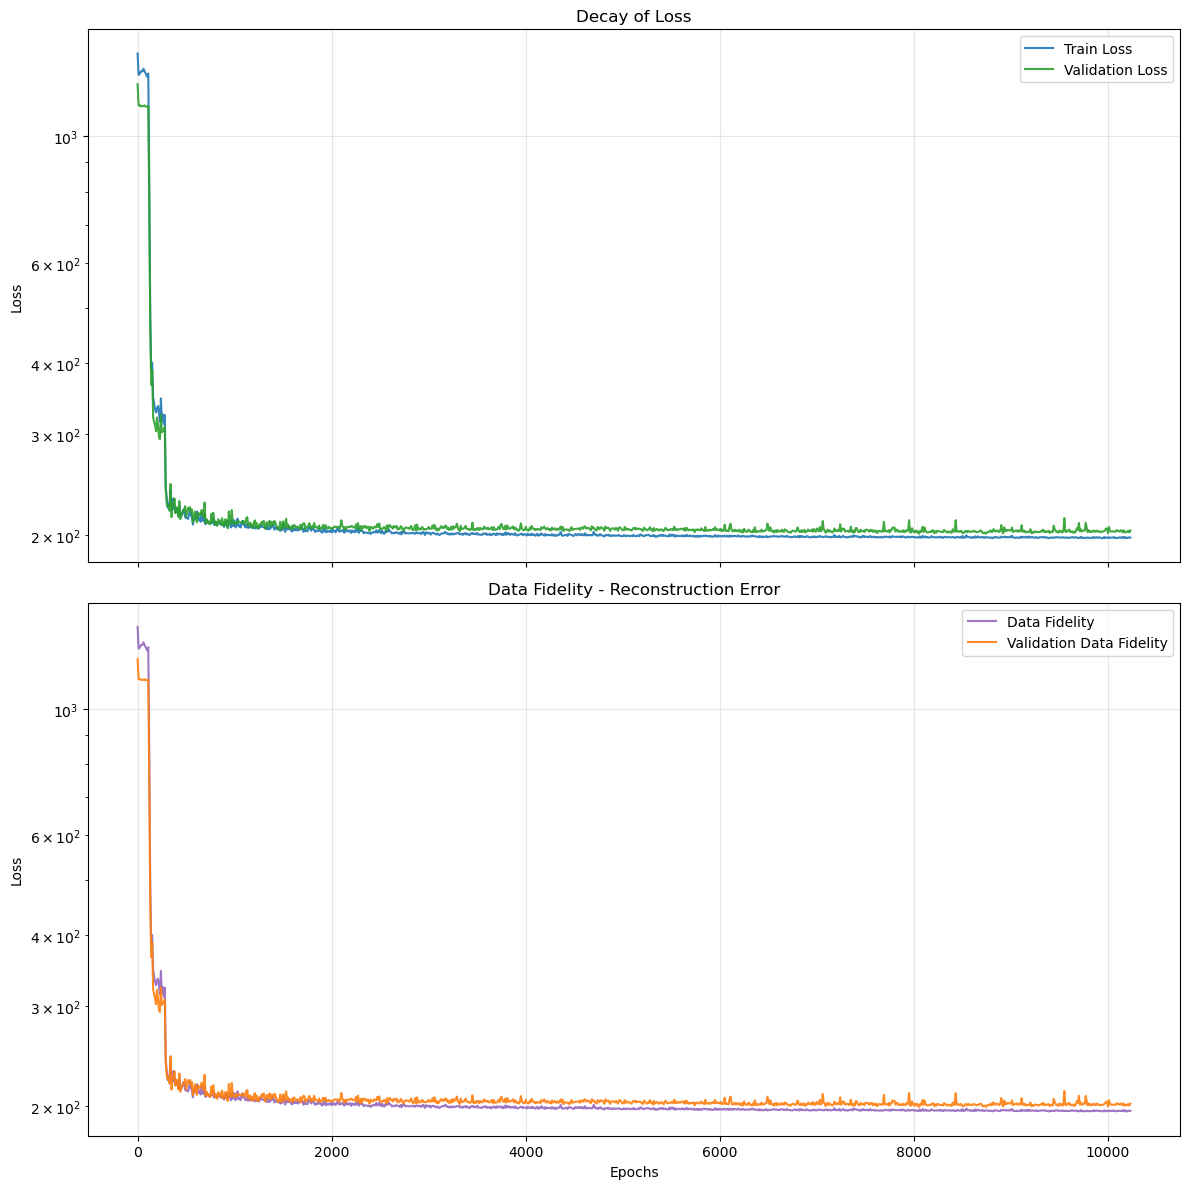

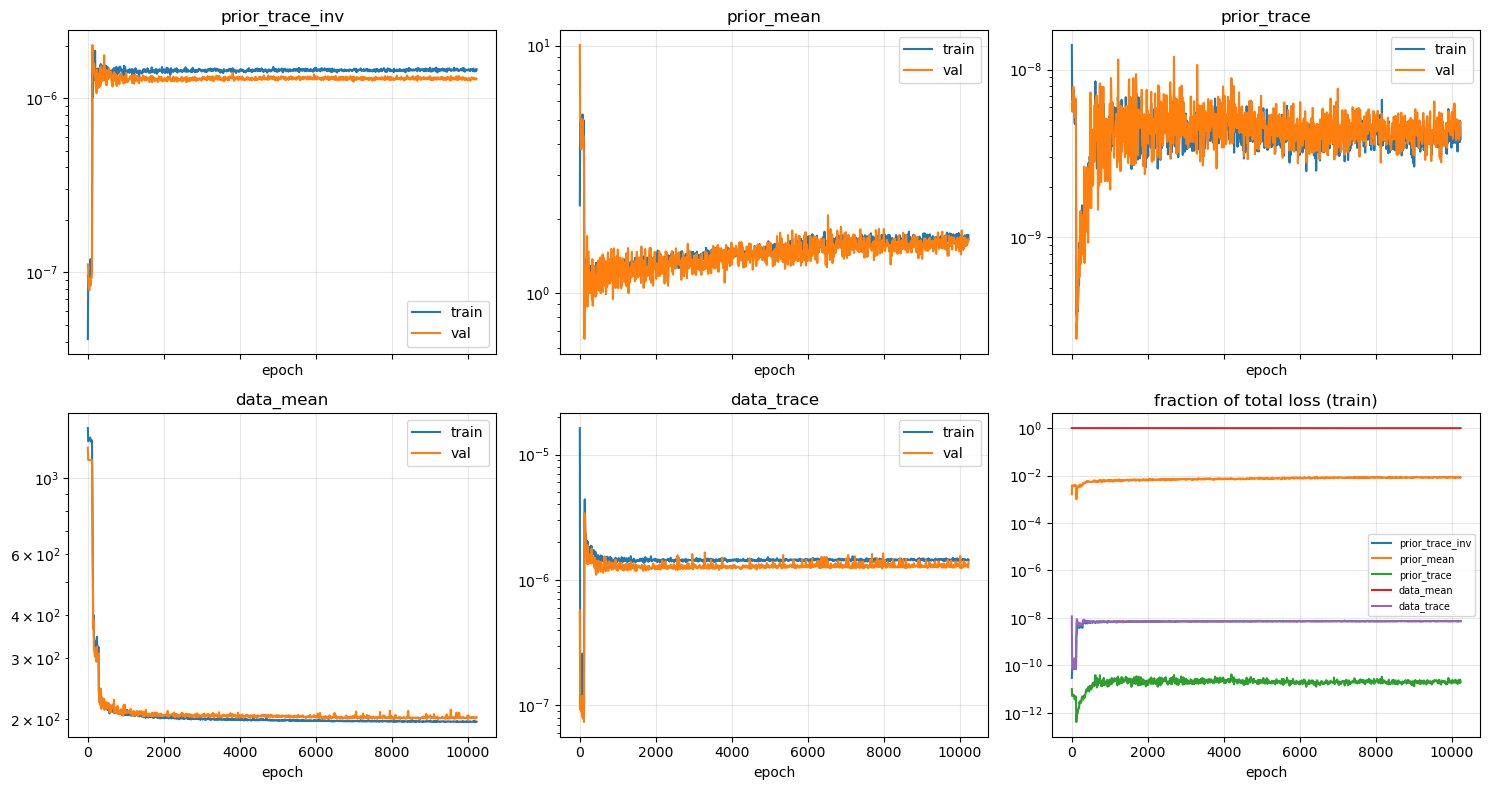

MAE Validation on cx: 0.0482
MAE Validation on cy: 0.0425


True vs Pred (first 5 samples Validation):
True [cx, cy]: [0.215      0.66799998] | Pred [cx, cy]: [0.31747085 0.6633265 ]
True [cx, cy]: [0.32300001 0.75099999] | Pred [cx, cy]: [0.54951525 0.28214845]
True [cx, cy]: [0.28200001 0.66799998] | Pred [cx, cy]: [0.37186736 0.6871939 ]
True [cx, cy]: [0.51800001 0.38100001] | Pred [cx, cy]: [0.56458837 0.4095025 ]
True [cx, cy]: [0.68599999 0.61699998] | Pred [cx, cy]: [0.6860883 0.6201851]

MAE Test on cx: 0.0466
MAE Test on cy: 0.0410
Coverage (target 68.3%): 77.23%
Coverage (target 95.0%): 89.11%


COMPLETED FULL PIPELINE FOR GRID 100x100



[ENCODER] Adam for grid 200x200
[SENSORS] Used sensors saved in: data/multiresolution/sensor_idx.npy
Shape y_train: (799, 200)  |  Shape u_train: (799, 2)
Shape y_val:   (99, 200)  |  Shape u_val:   (99, 2)
Shape y_test:  (101, 200)  |  Shape u_test:  (101, 2)
sigma_noise (scaled): 0.01965
Decoder weights loaded: models/error_analysis/200x2

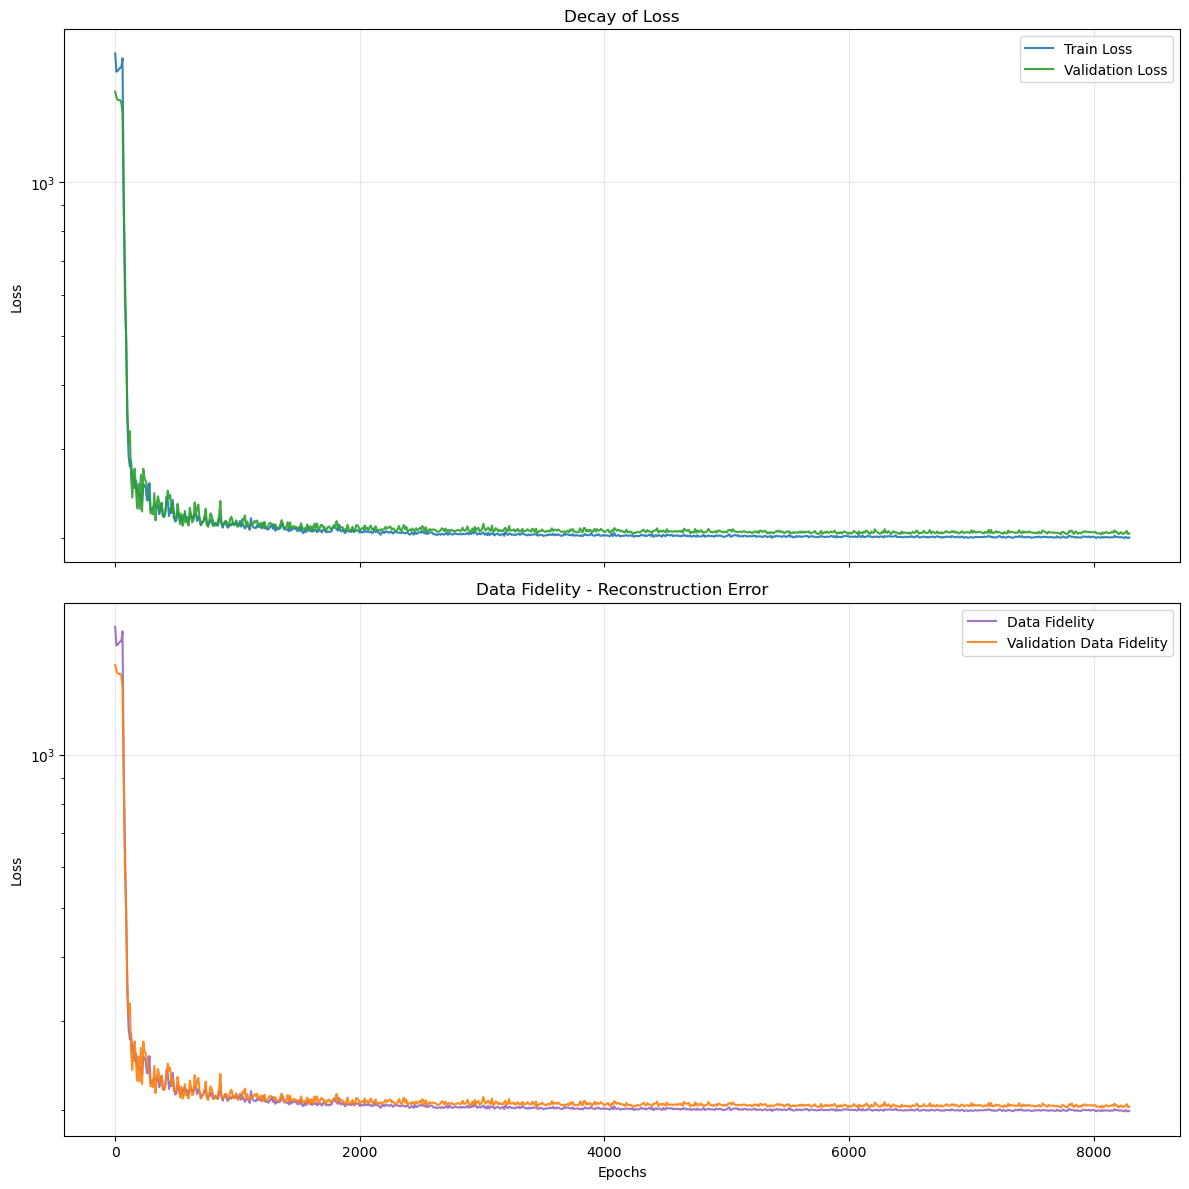

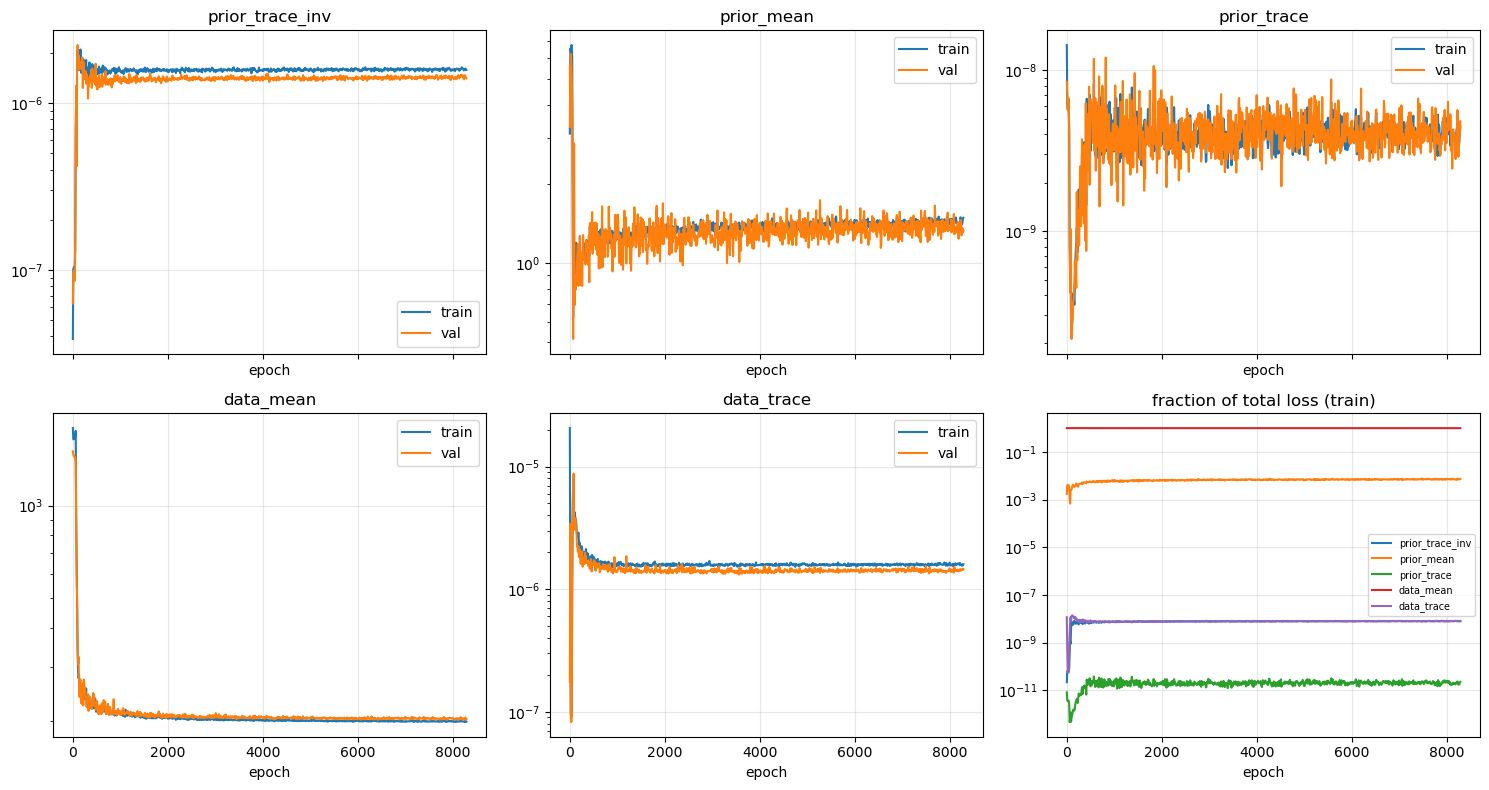

MAE Validation on cx: 0.0586
MAE Validation on cy: 0.0503


True vs Pred (first 5 samples Validation):
True [cx, cy]: [0.215      0.66799998] | Pred [cx, cy]: [0.3282269  0.64613944]
True [cx, cy]: [0.32300001 0.75099999] | Pred [cx, cy]: [0.57467353 0.27027968]
True [cx, cy]: [0.28200001 0.66799998] | Pred [cx, cy]: [0.2637374 0.6405299]
True [cx, cy]: [0.51800001 0.38100001] | Pred [cx, cy]: [0.5340111  0.40236706]
True [cx, cy]: [0.68599999 0.61699998] | Pred [cx, cy]: [0.6846489  0.61727226]

MAE Test on cx: 0.0547
MAE Test on cy: 0.0486
Coverage (target 68.3%): 81.19%
Coverage (target 95.0%): 88.12%


COMPLETED FULL PIPELINE FOR GRID 200x200



[ENCODER] Adam for grid 400x400
[SENSORS] Used sensors saved in: data/multiresolution/sensor_idx.npy
Shape y_train: (799, 200)  |  Shape u_train: (799, 2)
Shape y_val:   (99, 200)  |  Shape u_val:   (99, 2)
Shape y_test:  (101, 200)  |  Shape u_test:  (101, 2)
sigma_noise (scaled): 0.01965
Decoder weights loaded: models/error_analysis/400x4

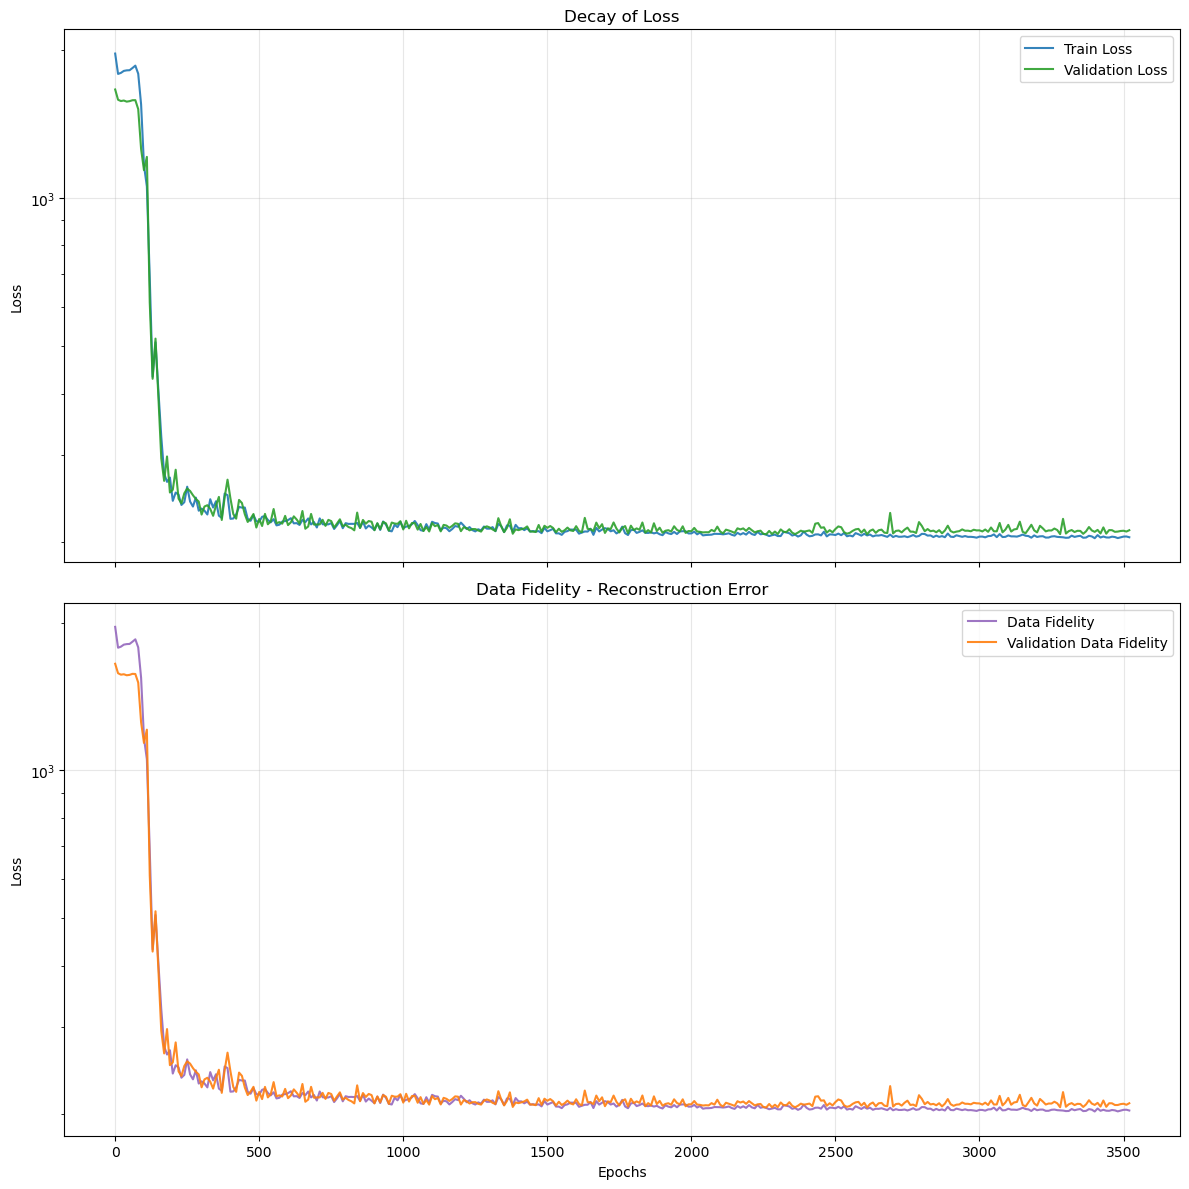

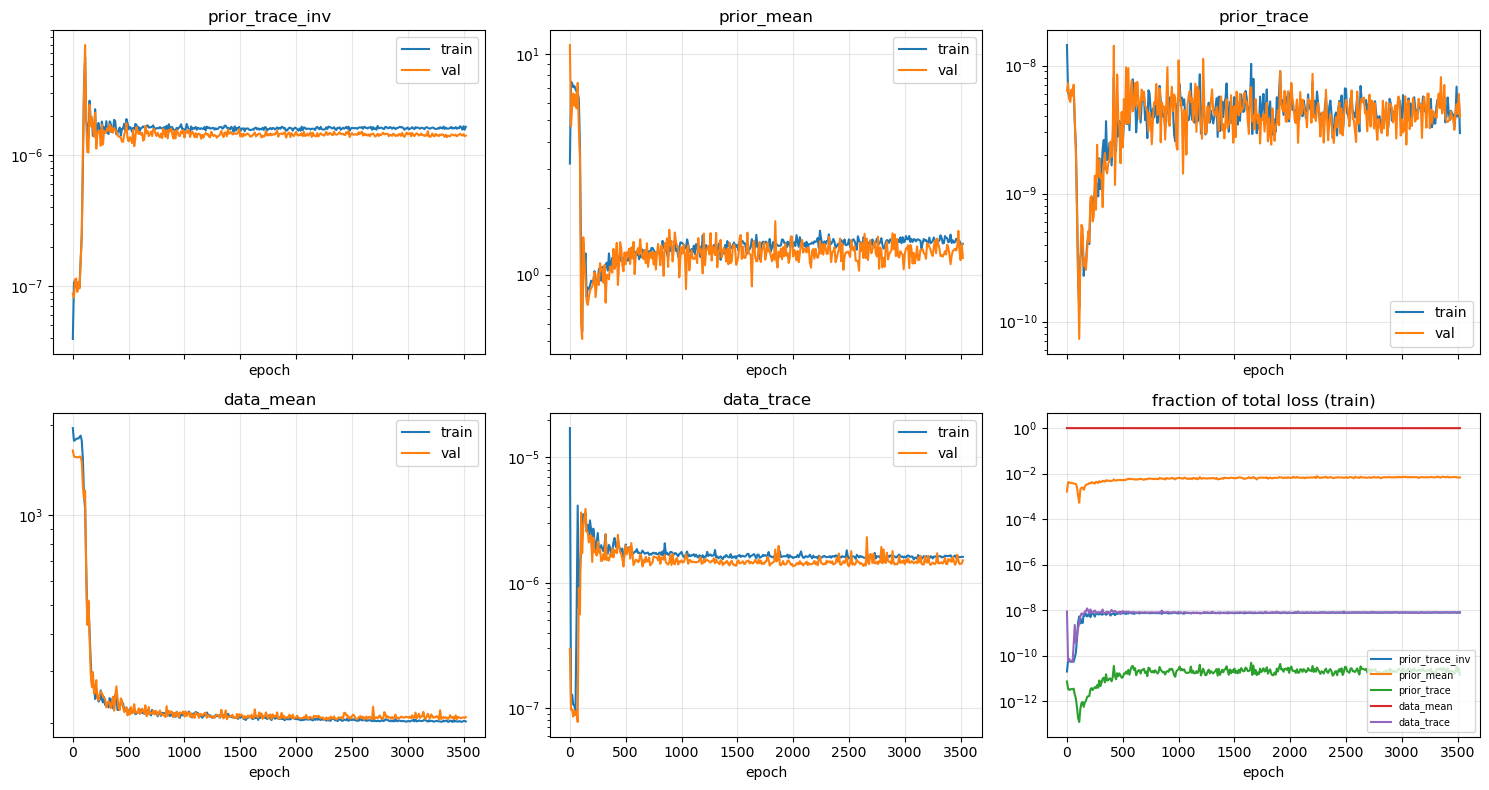

MAE Validation on cx: 0.0635
MAE Validation on cy: 0.0548


True vs Pred (first 5 samples Validation):
True [cx, cy]: [0.215      0.66799998] | Pred [cx, cy]: [0.36005297 0.54343444]
True [cx, cy]: [0.32300001 0.75099999] | Pred [cx, cy]: [0.4348605 0.3326726]
True [cx, cy]: [0.28200001 0.66799998] | Pred [cx, cy]: [0.3586291 0.7090136]
True [cx, cy]: [0.51800001 0.38100001] | Pred [cx, cy]: [0.54426885 0.3978741 ]
True [cx, cy]: [0.68599999 0.61699998] | Pred [cx, cy]: [0.68632334 0.616837  ]

MAE Test on cx: 0.0597
MAE Test on cy: 0.0548
Coverage (target 68.3%): 73.27%
Coverage (target 95.0%): 83.17%


COMPLETED FULL PIPELINE FOR GRID 400x400



[ENCODER] Adam for grid 800x800
[SENSORS] Used sensors saved in: data/multiresolution/sensor_idx.npy
Shape y_train: (799, 200)  |  Shape u_train: (799, 2)
Shape y_val:   (99, 200)  |  Shape u_val:   (99, 2)
Shape y_test:  (101, 200)  |  Shape u_test:  (101, 2)
sigma_noise (scaled): 0.01962
Decoder weights loaded: models/error_analysis/800x800

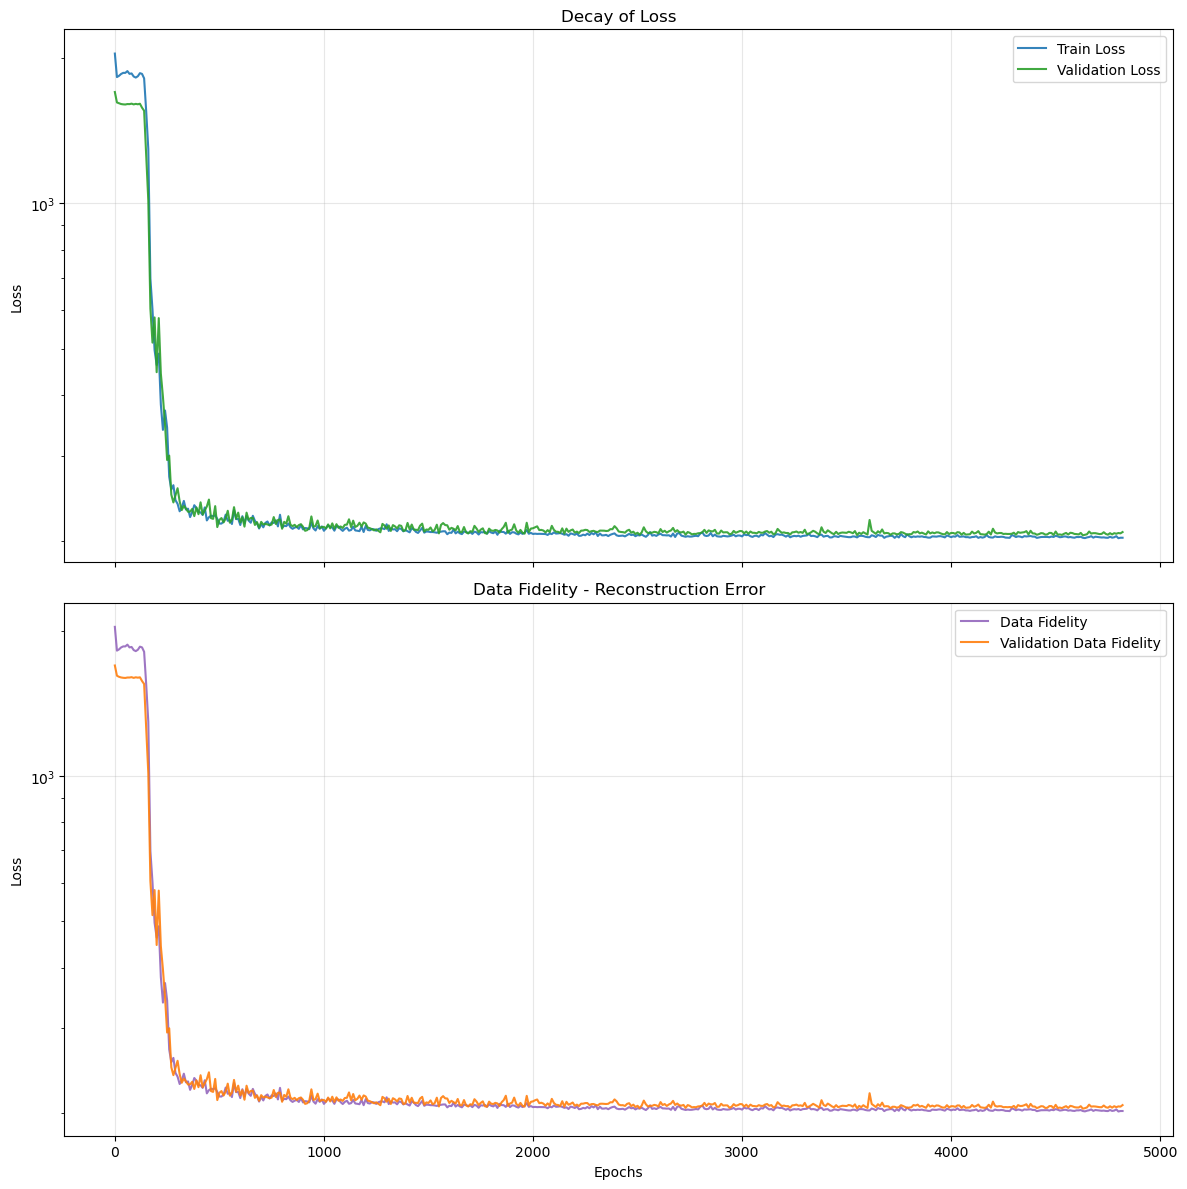

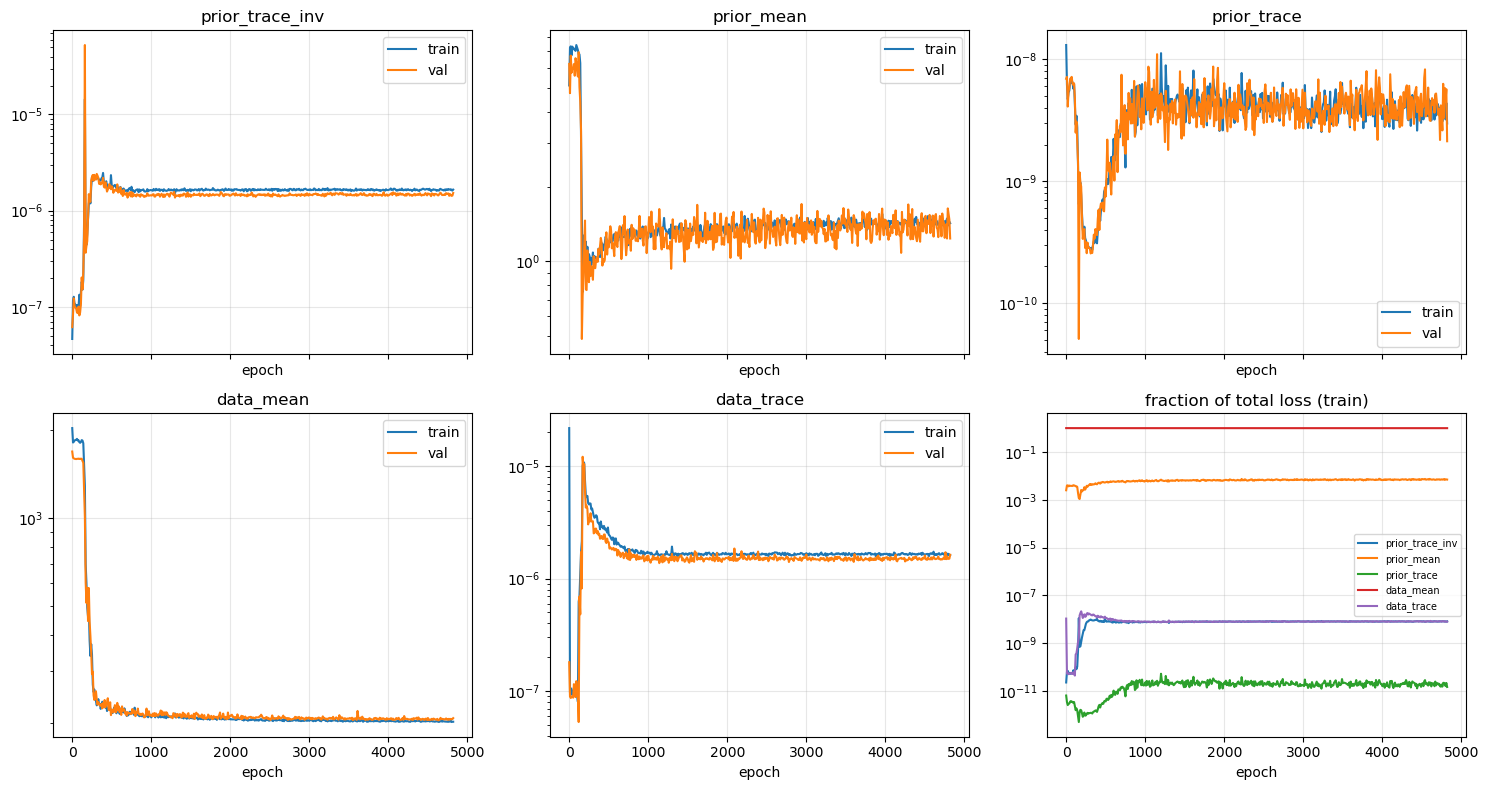

MAE Validation on cx: 0.0591
MAE Validation on cy: 0.0576


True vs Pred (first 5 samples Validation):
True [cx, cy]: [0.215      0.66799998] | Pred [cx, cy]: [0.33060282 0.64760935]
True [cx, cy]: [0.32300001 0.75099999] | Pred [cx, cy]: [0.47660583 0.30893996]
True [cx, cy]: [0.28200001 0.66799998] | Pred [cx, cy]: [0.35386813 0.7270902 ]
True [cx, cy]: [0.51800001 0.38100001] | Pred [cx, cy]: [0.55869627 0.39770758]
True [cx, cy]: [0.68599999 0.61699998] | Pred [cx, cy]: [0.68730295 0.61634654]

MAE Test on cx: 0.0592
MAE Test on cy: 0.0596
Coverage (target 68.3%): 72.28%
Coverage (target 95.0%): 82.18%


COMPLETED FULL PIPELINE FOR GRID 800x800




In [3]:
print("\n\nTRAINING - ENCODER PHASE\n\n")
for N in resolutions:
    grid_name = f"{N}x{N}"
    data_dir = os.path.join(base_data_dir, grid_name)

    model_dir = os.path.join('models', 'error_analysis', grid_name)
    os.makedirs(model_dir, exist_ok=True)

    result_dir = os.path.join('results', 'error_analysis', grid_name)
    os.makedirs(result_dir, exist_ok=True)
    
    metrics_file = os.path.join(model_dir, "metrics.json")
    
    with open(metrics_file, 'r') as f:
        res_metrics = json.load(f)

    if 'encoder' in res_metrics.get("times", {}):
        print(f"[{grid_name}] Encoder already trained. Skipping.")
        continue
        
    print(f"\n[ENCODER] Adam for grid {grid_name}")
    encoder, mae_cx, mae_cy, cov_68, cov_95, t_enc = train_and_evaluate_encoder(
        decoder_model=None, output_dir=model_dir, result_dir=result_dir, data_dir=data_dir)
    
    res_metrics['times']['encoder'] = t_enc
    res_metrics['errors']['enc_mae_cx'] = float(mae_cx)
    res_metrics['errors']['enc_mae_cy'] = float(mae_cy)
    res_metrics['errors']['enc_cov_68'] = float(cov_68)
    res_metrics['errors']['enc_cov_95'] = float(cov_95)
    
    with open(metrics_file, 'w') as f:
        json.dump(res_metrics, f, indent=4)
    print(f"\n\nCOMPLETED FULL PIPELINE FOR GRID {grid_name}\n\n")

In [4]:
print("\n\nMETRICS and CONVERGENCE\n\n")

results = []
for N in resolutions:
    metrics_file = os.path.join('models', 'error_analysis', f"{N}x{N}", "metrics.json")
    with open(metrics_file, 'r') as f:
        results.append(json.load(f))
for i in range(len(results)):
    if i == 0:
        results[i]['errors']['pinn_eoc'] = "-"
    else:
        N_prev = int(results[i-1]['Grid'].split('x')[0])
        N_curr = int(results[i]['Grid'].split('x')[0])
        h_prev, h_curr = 1.0 / N_prev, 1.0 / N_curr
        
        err_prev = results[i-1]['errors'].get('pinn_l2_rel', 0)
        err_curr = results[i]['errors'].get('pinn_l2_rel', 0)
        
        if err_prev > 0 and err_curr > 0:
            eoc = np.log(err_curr / err_prev) / np.log(h_curr / h_prev)
            results[i]['errors']['pinn_eoc'] = round(eoc, 2)
        else:
            results[i]['errors']['pinn_eoc'] = "-"

csv_rows = []
header = f"{'Grid':<10} | {'t_tot (s)':<10} | {'PINN L2':<10} | {'PINN EOC':<10} | {'Cov cx %':<10} | {'Cov cy %':<10} | {'Cov 68 %':<10}| {'Cov 95 %':<10}"
print(header)
print("-" * len(header))

for r in results:
    t_tot = sum(r['times'].values())
    errs = r['errors']
    
    pinn_eoc = errs.get('pinn_eoc', '-')
    eoc_str = f"{pinn_eoc:<10.2f}" if isinstance(pinn_eoc, float) else f"{pinn_eoc:<10}"
    
    print(f"{r['Grid']:<10} | {t_tot:<10.2f} | {errs.get('pinn_l2_rel', 0):<10.4f} | {eoc_str} | {errs.get('enc_mae_cx', 0):<10.4f} | {errs.get('enc_mae_cy', 0):<10.4f} | {errs.get('enc_cov_68', 0):<10.2f} | {errs.get('enc_cov_95', 0):<10.2f}")
    
    csv_rows.append({
        'Grid': r['Grid'],
        'u_scale': r.get('u_scale', 1.0),
        't_fem': r['times'].get('fem_generation', 0),
        't_dec_adam': r['times'].get('decoder_adam', 0),
        't_dec_lbfgs': r['times'].get('decoder_lbfgs', 0),
        't_enc': r['times'].get('encoder', 0),
        'pinn_l2_rel': errs.get('pinn_l2_rel', 0),
        'pinn_mae': errs.get('pinn_mae', 0),
        'pinn_eoc': pinn_eoc,
        'enc_mae_cx': errs.get('enc_mae_cx', 0),
        'enc_mae_cy': errs.get('enc_mae_cy', 0),
        'enc_cov_68': errs.get('enc_cov_68', 0),
        'enc_cov_95': errs.get('enc_cov_95', 0)
    })

result_dir = os.path.join('results', 'error_analysis', grid_name)
os.makedirs(result_dir, exist_ok=True)
csv_path = os.path.join(result_dir, 'grid_convergence_metrics.csv')

with open(csv_path, mode='w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=csv_rows[0].keys())
    writer.writeheader()
    writer.writerows(csv_rows)
    
print(f"\nResults saved to: {csv_path}\n")



METRICS and CONVERGENCE


Grid       | t_tot (s)  | PINN L2    | PINN EOC   | Cov cx %   | Cov cy %   | Cov 68 %  | Cov 95 %  
----------------------------------------------------------------------------------------------------
100x100    | 4492.66    | 0.0206     | -          | 0.0466     | 0.0410     | 77.23      | 89.11     
200x200    | 3484.64    | 0.0146     | 0.49       | 0.0547     | 0.0486     | 81.19      | 88.12     
400x400    | 1937.06    | 0.0141     | 0.06       | 0.0597     | 0.0548     | 73.27      | 83.17     
800x800    | 2376.86    | 0.0133     | 0.08       | 0.0592     | 0.0596     | 72.28      | 82.18     

Results saved to: results/error_analysis/800x800/grid_convergence_metrics.csv



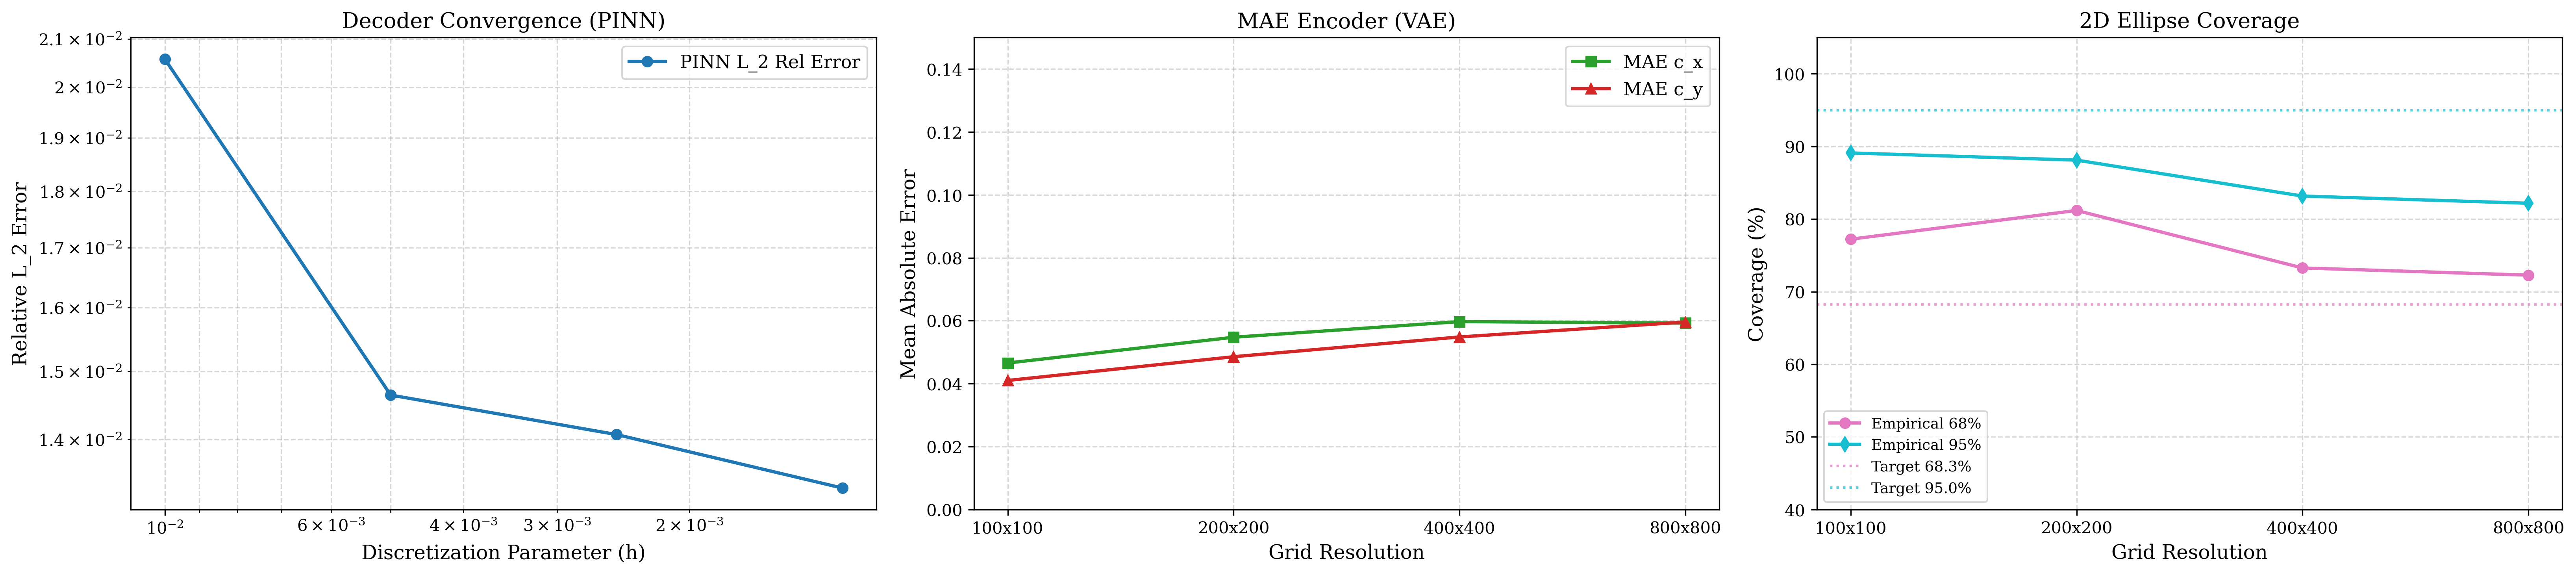

In [5]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300
})

grids_plot = [r['Grid'] for r in results]
h_vals = np.array([1/int(g.split('x')[0]) for g in grids_plot])

pinn_l2_rel = np.array([r['errors'].get('pinn_l2_rel', 0) for r in results])
enc_mae_cx = np.array([r['errors'].get('enc_mae_cx', 0) for r in results])
enc_mae_cy = np.array([r['errors'].get('enc_mae_cy', 0) for r in results])
enc_cov_68 = np.array([r['errors'].get('enc_cov_68', 0) for r in results])
enc_cov_95 = np.array([r['errors'].get('enc_cov_95', 0) for r in results])

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Plot 1: PINN Error
axes[0].loglog(h_vals, pinn_l2_rel, 'o-', color='#1f77b4', linewidth=2, markersize=6, label='PINN L_2 Rel Error')
axes[0].set_title("Decoder Convergence (PINN)")
axes[0].set_xlabel("Discretization Parameter (h)")
axes[0].set_ylabel("Relative L_2 Error")
axes[0].grid(True, which="both", ls="--", alpha=0.5)
axes[0].invert_xaxis()
axes[0].legend(frameon=True)

# Plot 2: Encoder MAE
x_indexes = np.arange(len(grids_plot))
axes[1].plot(x_indexes, enc_mae_cx, 's-', color='#2ca02c', linewidth=2, markersize=6, label='MAE c_x')
axes[1].plot(x_indexes, enc_mae_cy, '^-', color='#d62728', linewidth=2, markersize=6, label='MAE c_y')
axes[1].set_title("MAE Encoder (VAE)")
axes[1].set_xlabel("Grid Resolution")
axes[1].set_ylabel("Mean Absolute Error")
axes[1].set_xticks(x_indexes)
axes[1].set_xticklabels(grids_plot)
axes[1].set_ylim(0, 0.15)
axes[1].grid(True, ls="--", alpha=0.5)
axes[1].legend(frameon=True)

# Plot 3: Encoder Coverage
axes[2].plot(x_indexes, enc_cov_68, 'o-', color='#e377c2', linewidth=2, markersize=6, label='Empirical 68%')
axes[2].plot(x_indexes, enc_cov_95, 'd-', color='#17becf', linewidth=2, markersize=6, label='Empirical 95%')
axes[2].axhline(68.27, color='#e377c2', linestyle=':', alpha=0.7, label='Target 68.3%')
axes[2].axhline(95.00, color='#17becf', linestyle=':', alpha=0.7, label='Target 95.0%')
axes[2].set_title("2D Ellipse Coverage")
axes[2].set_xlabel("Grid Resolution")
axes[2].set_ylabel("Coverage (%)")
axes[2].set_xticks(x_indexes)
axes[2].set_xticklabels(grids_plot)
axes[2].set_ylim(40, 105)
axes[2].grid(True, ls="--", alpha=0.5)
axes[2].legend(frameon=True, loc='lower left', fontsize=9)

plt.tight_layout()
plots_dir = os.path.join(result_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)
save_path = os.path.join(plots_dir, "uq_vae_convergence_summary.png")
plt.savefig(save_path)
plt.show()